# SLSN Multi-Model Comparison Notebook

Cross-model analysis across all 3 rate models × 4 cadences.
Loads from saved summary CSVs, `.npy` metric arrays, and population pickles — **no rerunning metrics**.

## Structure
- **Cell 1**: Setup, paths, and configuration
- **Cell 2**: Load all 3 summary CSVs → combined DataFrame
- **Cell 3**: Summary table (detections/yr, efficiency — all 12 combos)
- **Cell 4**: Bar chart — detections/yr by cadence, grouped by model (Detect metric)
- **Cell 5**: Bar chart — all 3 metrics side by side (Detect / Characterize / SpecTrigger)
- **Cell 6**: Load populations + .npy arrays for z-bin analysis
- **Cell 7**: Adam's z-bins: efficiency vs redshift for all 3 models × baseline cadence
- **Cell 8**: Adam's fixed bins z=1.3–1.7: table of detections + efficiency per model
- **Cell 9**: HEALPix sky map — Detect efficiency, fe_dependent × baseline (reference)

## Reload flags
- **Templates**: NO reload — only loaded in Cell 6 to support population loading
- **Population**: NO reload — loading from existing PKL files
- **Mag grid**: NO reload
- **Kernel restart**: Only if you edit a `.py` module and need `reload()` to pick it up

In [1]:
# ============================================================================
# CELL 1: Setup and configuration
# ============================================================================
import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import healpy as hp
from pathlib import Path
from importlib import reload

# --- Repo path ---
REPO = Path('/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric')
sys.path.insert(0, str(REPO / 'py_files'))
from slsn_metrics.paths import get_shared_output_dir, get_output_dir, get_rate_csv_path
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import (
    plot_population_rate_vs_redshift,
    plot_healpix_efficiency,
)

# --- Configuration ---
# These are the 260407 production runs — use these files
MODELS   = ['fe_dependent', 'o_dependent', 'naive']
CADENCES = [
    'baseline_v5.1.1_10yrs',
    'four_roll_v5.0.0_10yrs',
    'noroll_v5.0.0_10yrs',
    'poor_weather_v5.0.1_10yrs',
]
DATE_TAG     = '260409'    # ← production run date stamp
SURVEY_YEARS = 10
Z_MIN, Z_MAX = 0.1, 2.0
MJD0         = 60980.5

# --- Paths ---
SHARED_DIR = get_shared_output_dir('SLSNe')

# --- Verify summary CSVs exist ---
# These are the all-cadence combined CSVs written by run_slsn_multi_metrics_parallel
print('=== Summary CSV Check ===')
SUMMARY_FILES = {}
for model in MODELS:
    model_dir = get_output_dir('SLSNe', subdir=model)
    # Combined all-cadence summary file (one per model, written at end of parallel run)
    matches = sorted(model_dir.glob(f'summary_{model}_all_cadences_z{Z_MIN}-{Z_MAX}_*.csv'))
    if matches:
        SUMMARY_FILES[model] = matches[-1]
        print(f'  OK  {model}: {matches[-1].name}')
    else:
        print(f'  MISSING  {model}: expected summary_{model}_all_cadences_z{Z_MIN}-{Z_MAX}_{DATE_TAG}.csv')

print(f'\nFound {len(SUMMARY_FILES)}/3 summary files')

=== Summary CSV Check ===
  OK  fe_dependent: summary_fe_dependent_all_cadences_z0.1-2.0_260408_1817.csv
  OK  o_dependent: summary_o_dependent_all_cadences_z0.1-2.0_260408_1817.csv
  OK  naive: summary_naive_all_cadences_z0.1-2.0_260408_1818.csv

Found 3/3 summary files


✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_evolution_comparison_260409.png


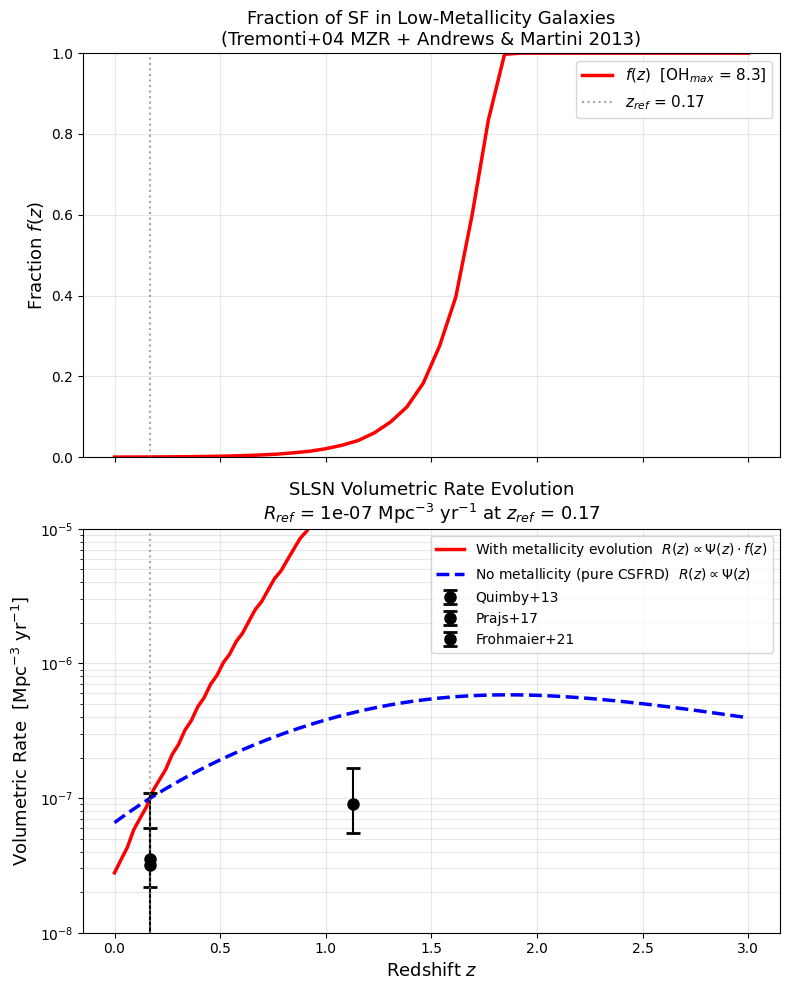

Saved: rate_evolution_comparison_260409.png


In [2]:
# ============================================================================
# CELL A: Rate evolution comparison — analytical R(z) curves (model-agnostic)
# Shows SFR × metallicity fraction vs pure-SFR curve + observed measurements.
# No population needed — call once for all models.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

out_rate_fig = get_output_dir('SLSNe') / f'rate_evolution_comparison_{DATE_TAG}.png'
plot_rate_evolution_comparison(save_path=out_rate_fig)
print(f'Saved: {out_rate_fig.name}')


In [3]:
# ============================================================================
# CELL 6: Load populations and .npy arrays for all metrics
# NO reload of templates or population needed — these are existing files
# ============================================================================
from slsn_metrics.model import LC
from slsn_metrics.population import generate_SLSN_PopSlicer
import glob

def find_npy(model_dir, model, cadence, metric_short):
    """Find the most recent .npy file matching model × cadence × metric."""
    pattern = str(model_dir / f'metric_values_{metric_short}_{model}_{cadence}_*.npy')
    matches = sorted(glob.glob(pattern))
    if not matches:
        raise FileNotFoundError(f'No file matching: {pattern}')
    if len(matches) > 1:
        print(f'  WARNING: multiple matches for {metric_short}, using latest: {Path(matches[-1]).name}')
    return Path(matches[-1])

# Metric short-names — must match what runners.py saves
METRIC_KEYS = ['detect', 'characterize', 'spectrigger', 'villar', 'elasticc']

# Load templates (required by generate_SLSN_PopSlicer loader)
print('Loading templates...')
templates = LC(load_from=str(SHARED_DIR / 'templates.pkl'))

pop_data = {}

for model in MODELS:
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    print(f'\nLoading {model}...')
    pop = generate_SLSN_PopSlicer(
        lc_model=templates,
        load_from=str(pop_pkl),
        make_debug_plots=False
    )
    z_vals  = np.asarray(pop.slice_points['z'])
    ra_rad  = np.asarray(pop.slice_points['ra'])
    dec_rad     = np.asarray(pop.slice_points['dec'])
    peak_times  = np.asarray(pop.slice_points['peak_time'])
    print(f'  {len(z_vals):,} events, z: {z_vals.min():.2f}–{z_vals.max():.2f}')

    # Load .npy for each metric × cadence
    metric_arrays = {m: {} for m in METRIC_KEYS}
    for metric in METRIC_KEYS:
        for cadence in CADENCES:
            try:
                npy_path = find_npy(model_dir, model, cadence, metric)
                metric_arrays[metric][cadence] = np.load(npy_path).astype(int)
                print(f'  Loaded {metric} .npy: {npy_path.name}')
            except FileNotFoundError:
                print(f'  MISSING: {metric} × {cadence}')
                metric_arrays[metric][cadence] = None

    pop_data[model] = {
        'z':           z_vals,
        'ra':          ra_rad,
        'dec':         dec_rad,
        'peak_time':   peak_times,
        'detect':      metric_arrays['detect'],
        'characterize': metric_arrays['characterize'],
        'spectrigger': metric_arrays['spectrigger'],
        'villar':      metric_arrays['villar'],
        'elasticc':    metric_arrays['elasticc']
    }

print('\n=== All populations and .npy arrays loaded ===')

Loading templates...

Loading fe_dependent...
[LOAD] Loaded 2243377 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent.pkl
  2,243,377 events, z: 0.10–2.00
  Loaded detect .npy: metric_values_detect_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260409_1712.npy
  Loaded detect .npy: metric_values_detect_fe_dependent_four_roll_v5.0.0_10yrs_z0.1-2.0_260409_1733.npy
  Loaded detect .npy: metric_values_detect_fe_dependent_noroll_v5.0.0_10yrs_z0.1-2.0_260409_1718.npy
  Loaded detect .npy: metric_values_detect_fe_dependent_poor_weather_v5.0.1_10yrs_z0.1-2.0_260409_1249.npy
  Loaded characterize .npy: metric_values_characterize_fe_dependent_baseline_v5.1.1_10yrs_z0.1-2.0_260409_1712.npy
  Loaded characterize .npy: metric_values_characterize_fe_dependent_four_roll_v5.0.0_10yrs_z0.1-2.0_260409_1733.npy
  Loaded characterize .npy: metric_values_characterize_fe_dependent_noroll_v5.0.0_10yrs_z0.1-2.0_260409_1718.npy
  Loaded char


=== Population diagnostics: fe_dependent ===
[LOAD] Loaded 2243377 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_fe_dependent.pkl


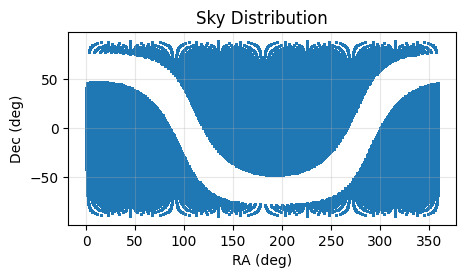

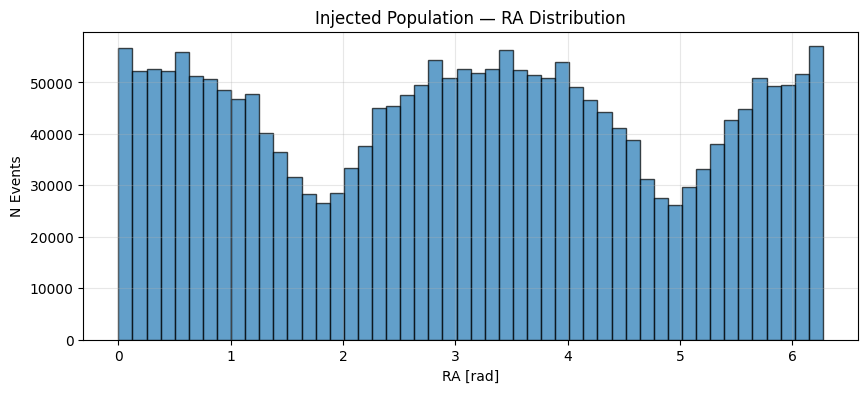

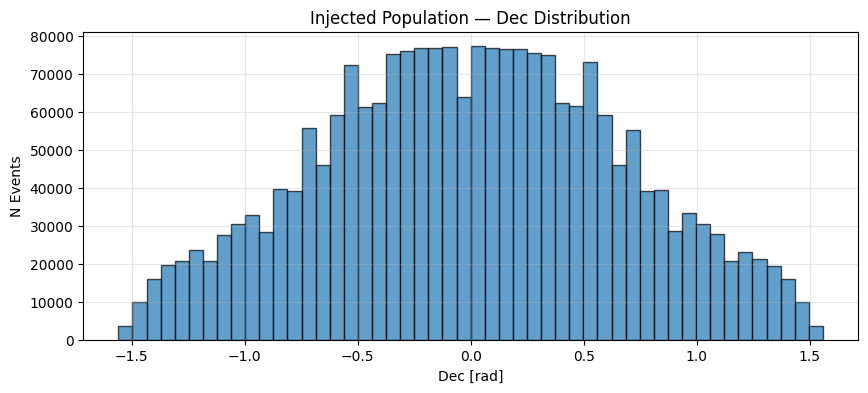

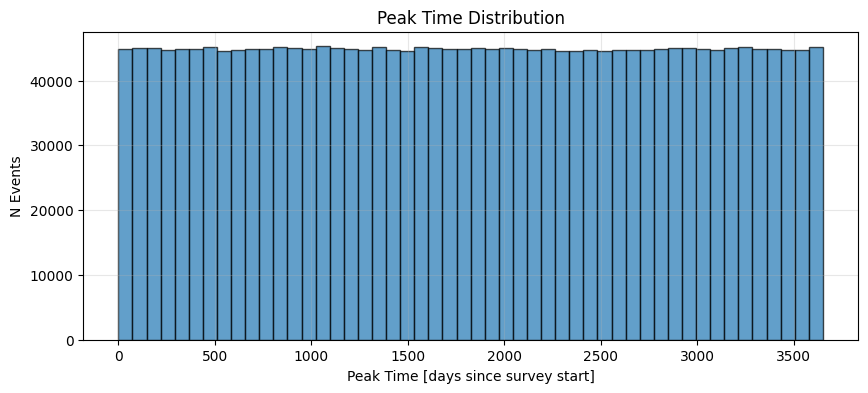

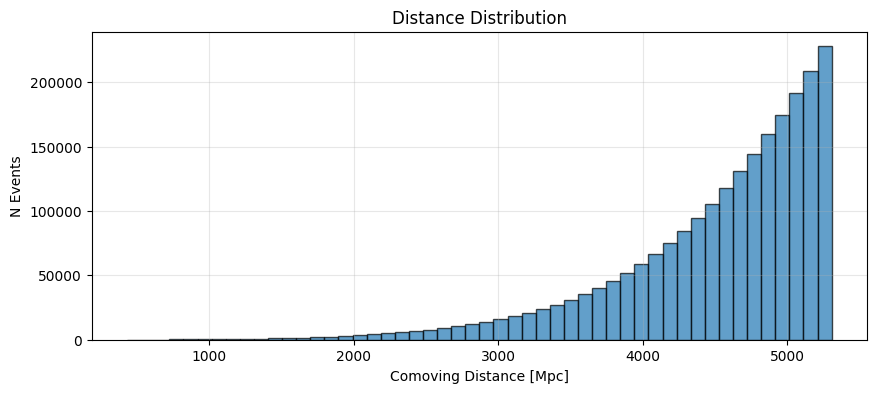

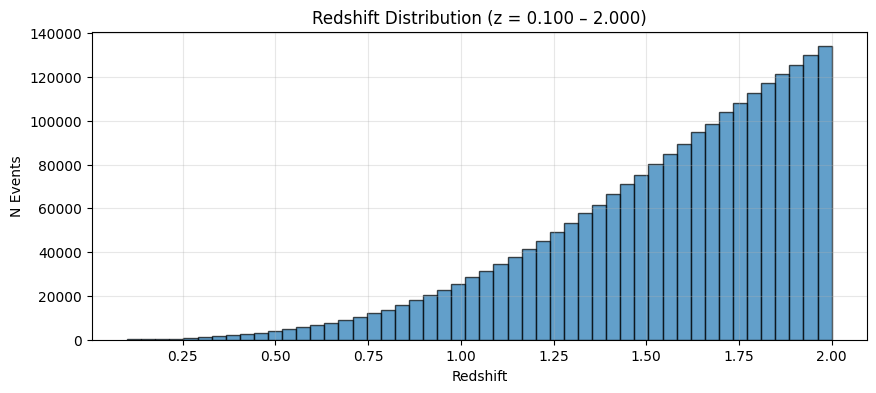

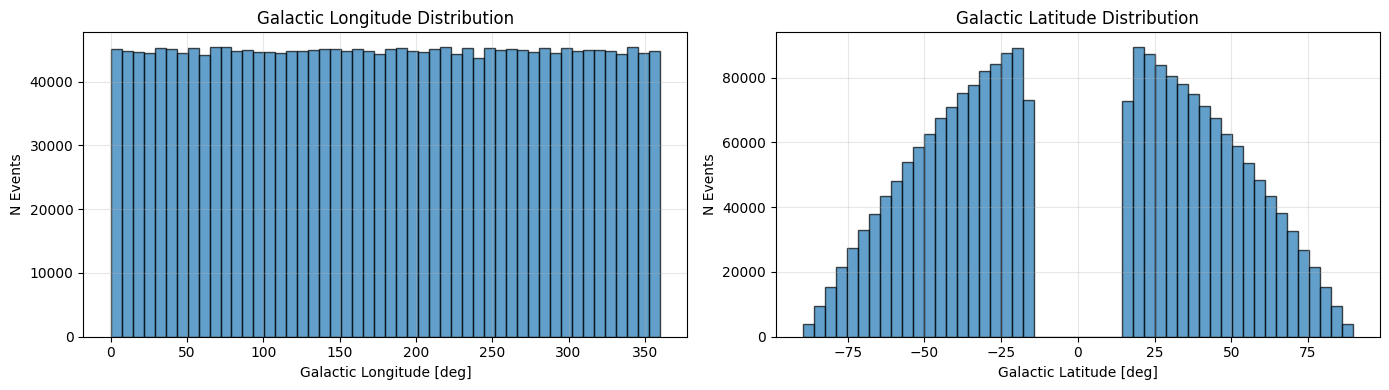

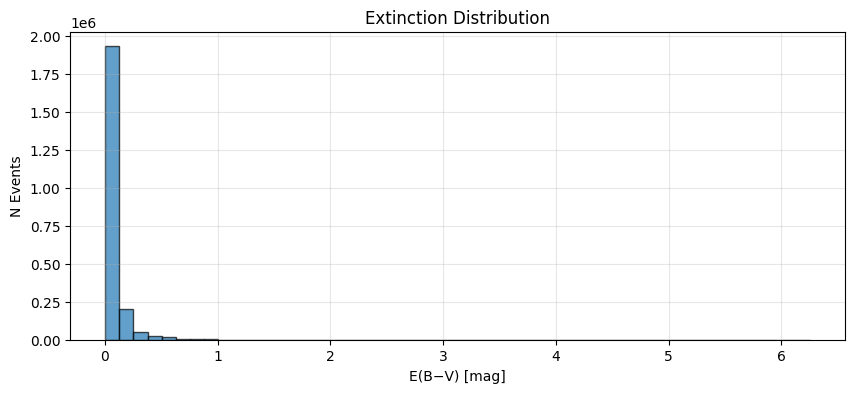


=== Population diagnostics: o_dependent ===
[LOAD] Loaded 1146435 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_o_dependent.pkl


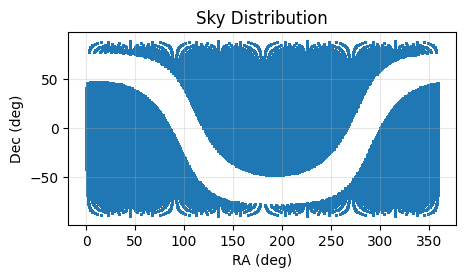

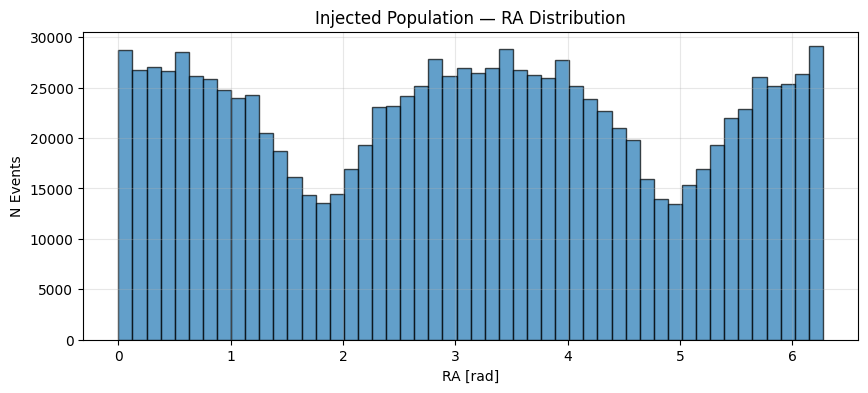

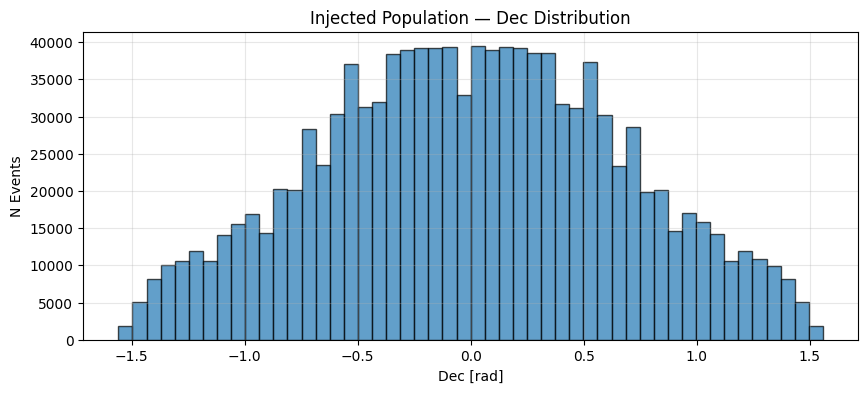

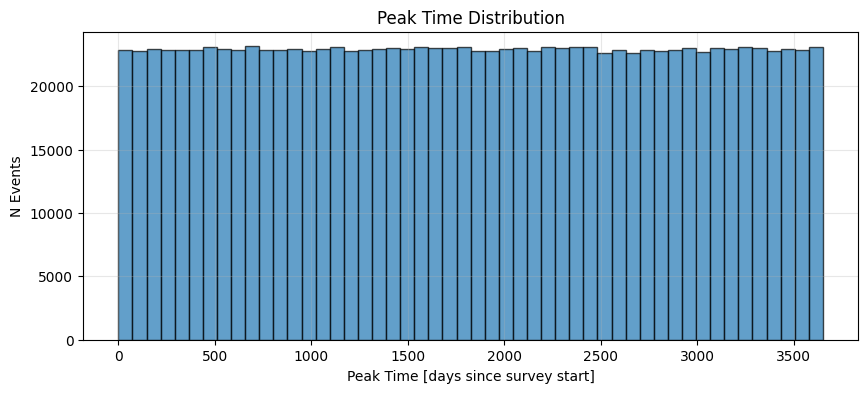

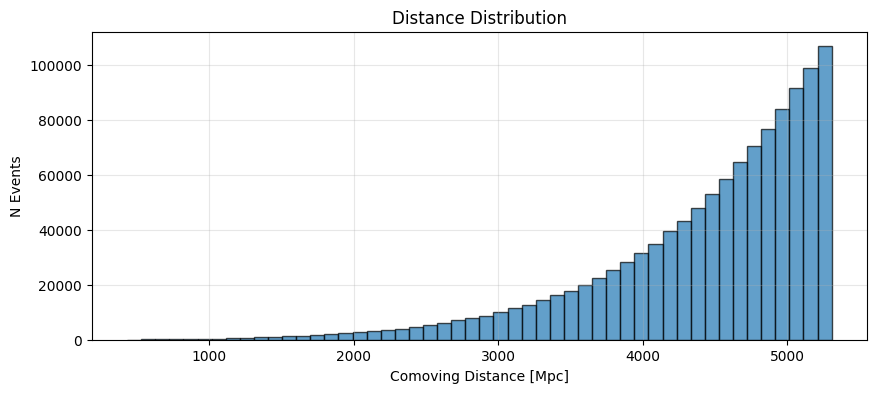

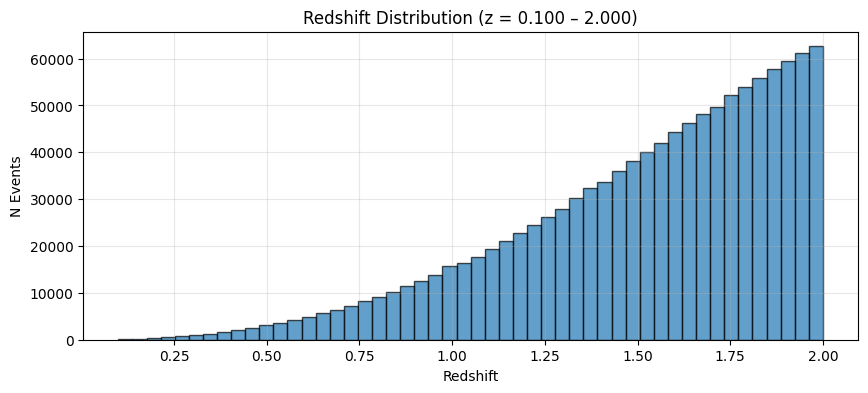

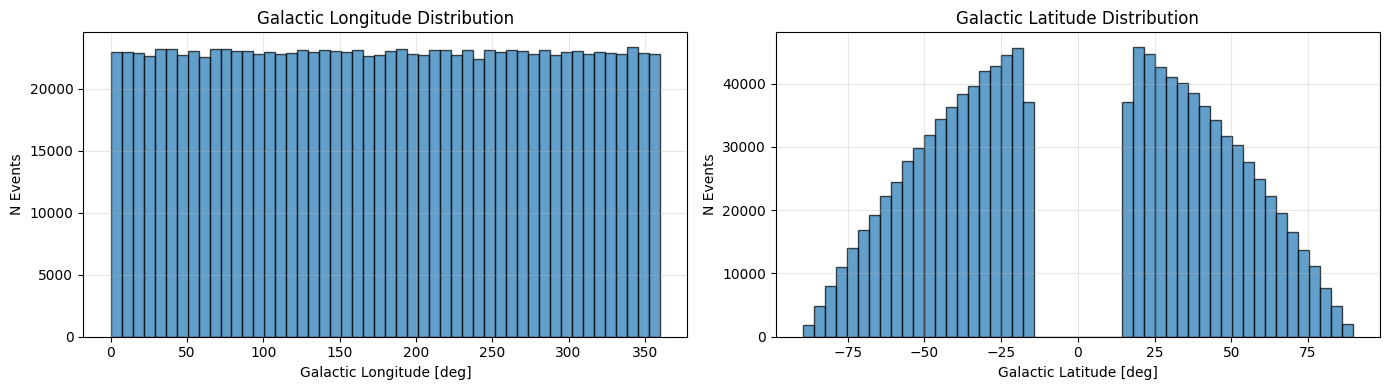

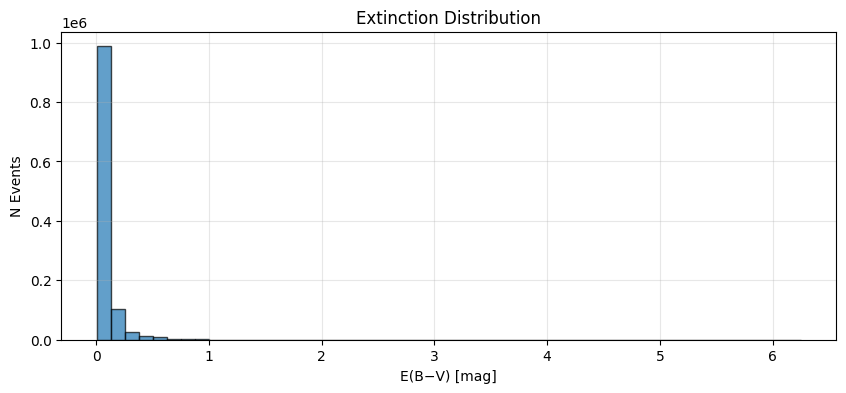


=== Population diagnostics: naive ===
[LOAD] Loaded 750598 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared/population_naive.pkl


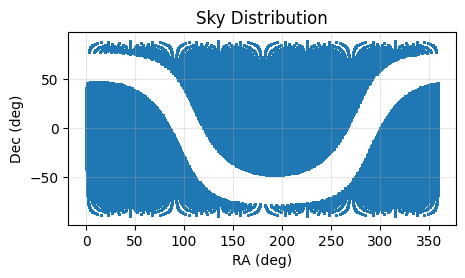

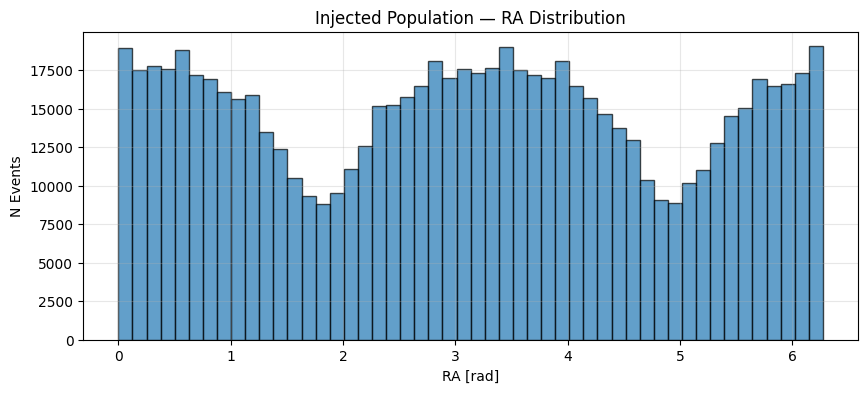

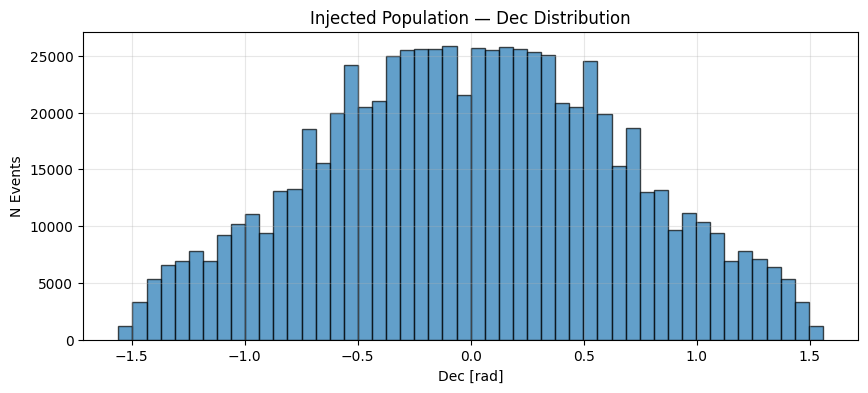

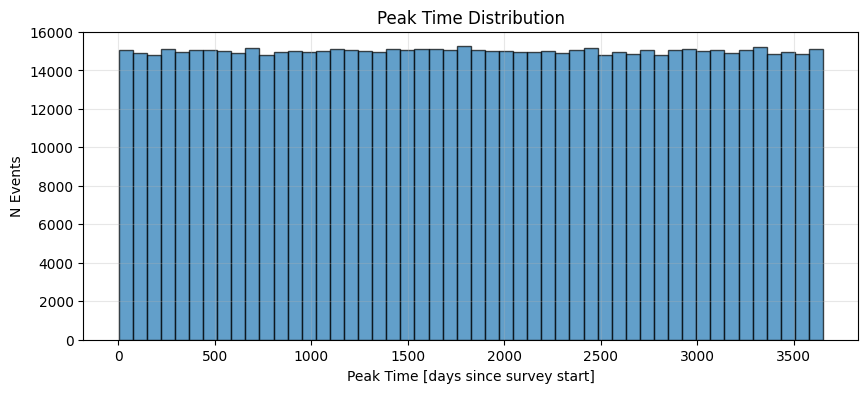

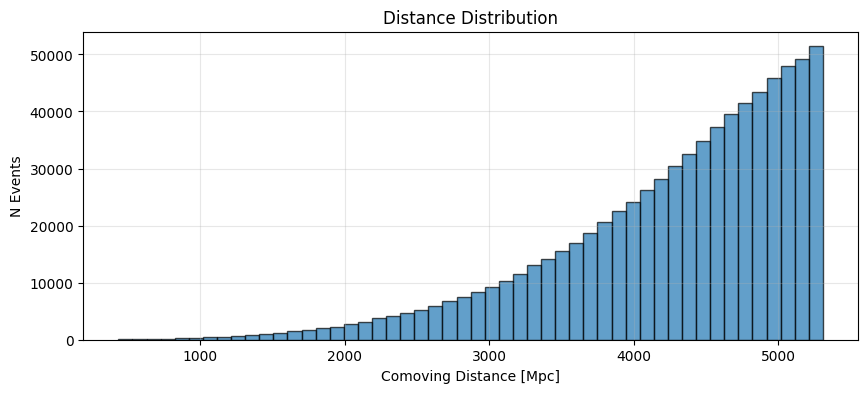

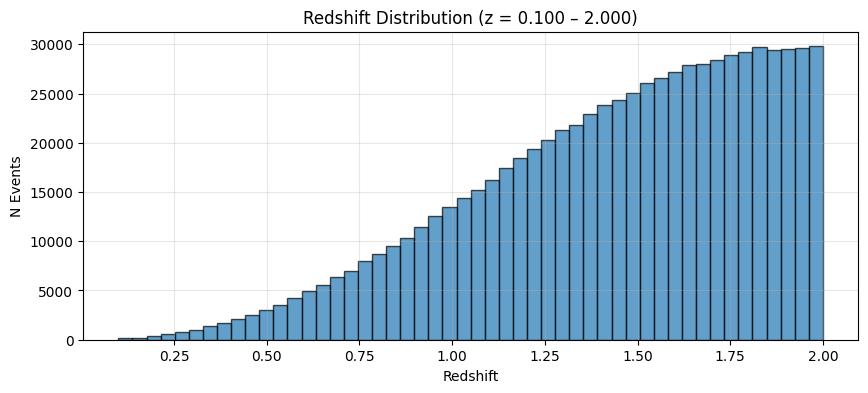

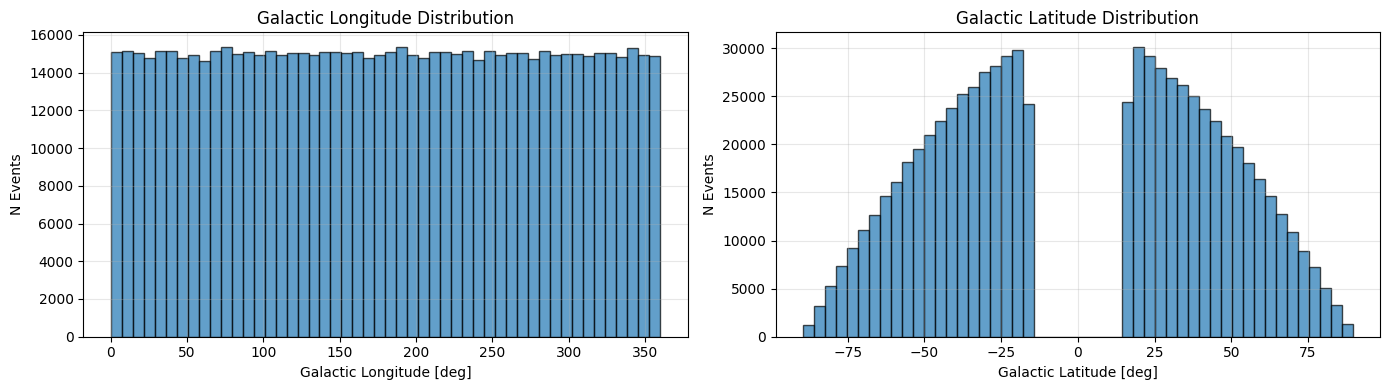

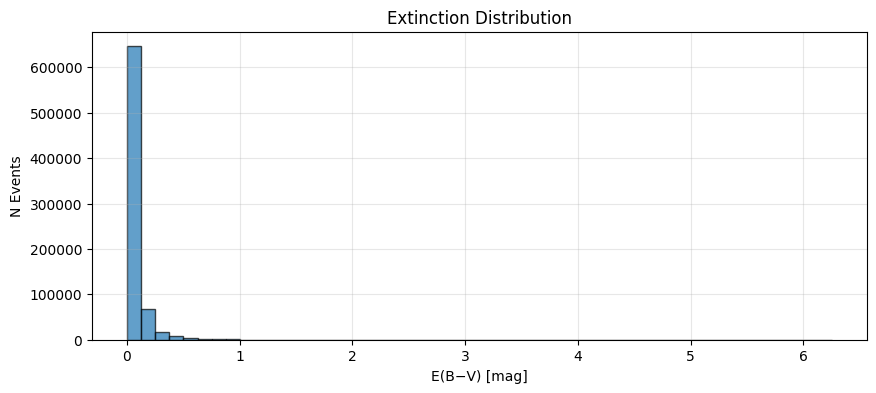

In [4]:
# ============================================================================
# CELL B: Population diagnostics — all 3 models
# plot_population_diagnostics needs distances_mpc, ebv, gall, galb which are
# not in pop_data — reload the slicer for each model.
# Also stores pop_slicers dict so Cells C and D can reuse without reloading.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_population_diagnostics

pop_slicers = {}

for model in MODELS:
    print(f'\n=== Population diagnostics: {model} ===')
    pop_pkl   = SHARED_DIR / f'population_{model}.pkl'
    model_dir = get_output_dir('SLSNe', subdir=model)

    pop = generate_SLSN_PopSlicer(
        lc_model=templates,
        load_from=str(pop_pkl),
        make_debug_plots=False
    )
    pop_slicers[model] = pop          # cache for Cells C and D
    sp = pop.slice_points

    plot_population_diagnostics(
        ra_rad        = sp['ra'],
        dec_rad       = sp['dec'],
        peak_times    = sp['peak_time'],
        distances_mpc = sp['distance'],
        z_vals        = sp['z'],
        ebv           = sp.get('ebv', None),
        gall          = sp.get('gall', None),
        galb          = sp.get('galb', None),
        outdir        = str(model_dir),
        prefix        = f'population_{model}'
    )


In [5]:
# ============================================================================
# CELL 2: Load all 3 summary CSVs into one combined DataFrame
# Each CSV has columns: cadence, metric, n_events, n_success, efficiency
# We add a 'model' column and compute 'per_year'
# ============================================================================
rows = []
for model, csv_path in SUMMARY_FILES.items():
    df_s = pd.read_csv(csv_path)
    df_s['model']    = model
    df_s['per_year'] = df_s['n_success'] / SURVEY_YEARS
    rows.append(df_s)

df_all = pd.concat(rows, ignore_index=True)

# Clean up cadence names for display (strip version/10yrs suffix)
cadence_labels = {
    'baseline_v5.1.1_10yrs':    'baseline',
    'four_roll_v5.0.0_10yrs':   'four_roll',
    'noroll_v5.0.0_10yrs':      'noroll',
    'poor_weather_v5.0.1_10yrs':'poor_weather',
}
df_all['cadence_short'] = df_all['cadence'].map(cadence_labels)

model_labels = {
    'fe_dependent': 'Fe-dependent',
    'o_dependent':  'O-dependent',
    'naive':        'Naive SFR',
}
df_all['model_label'] = df_all['model'].map(model_labels)

print(f'Loaded {len(df_all)} rows across {df_all["model"].nunique()} models')
print(f'Metrics present: {df_all["metric"].unique().tolist()}')

Loaded 60 rows across 3 models
Metrics present: ['SLSN_Detect_Metric', 'SLSN_CharacterizeMetric', 'SLSN_VillarMetric', 'SLSN_ELAsTiCC_Metric', 'SLSN_SpecTriggerMetric']


In [6]:
# ============================================================================
# CELL 3: Summary table — detections/yr and efficiency, all 12 combinations
# Primary reference table for the paper / collaborator email
# ============================================================================

detect_df = df_all[df_all['metric'] == 'SLSN_Detect_Metric'].copy()
char_df   = df_all[df_all['metric'] == 'SLSN_CharacterizeMetric'].copy()
spec_df   = df_all[df_all['metric'] == 'SLSN_SpecTriggerMetric'].copy()
villar_df = df_all[df_all['metric'] == 'SLSN_VillarMetric'].copy()
elasticc_df = df_all[df_all['metric'] =='SLSN_ELAsTiCC_Metric'].copy()

# Detections per year — pivot: rows=model, columns=cadence
pivot_per_yr = detect_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

# Efficiency [%] pivot
pivot_eff = detect_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='efficiency', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']] * 100

print('=== Detections per Year (Detect Metric) — 3 models × 4 cadences ===')
print(pivot_per_yr.round(0).to_string())

print('\n=== Detection Efficiency [%] ===')
print(pivot_eff.round(3).to_string())

# Population sizes for context
print('\n=== Population sizes (n_events) ===')
for model in MODELS:
    n = detect_df[detect_df['model'] == model]['n_events'].iloc[0]
    print(f'  {model:<15}: {n:>9,} events')

# Spectrigger per year
spec_pivot = spec_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== Spec Trigger per Year (mag_limit=23.0) ===')
print(spec_pivot.round(1).to_string())

# Villar per year
villar_pivot = villar_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== Villar Metric per Year ===')
print(villar_pivot.round(1).to_string())

# ELAsTiCC per year
elasticc_pivot = elasticc_df.pivot_table(
    index='model_label', columns='cadence_short',
    values='per_year', aggfunc='first'
)[['baseline', 'four_roll', 'noroll', 'poor_weather']]

print('\n=== ELAsTiCC Metric per Year ===')
print(elasticc_pivot.round(1).to_string())


=== Detections per Year (Detect Metric) — 3 models × 4 cadences ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      642.0      638.0   730.0         488.0
Naive SFR         330.0      325.0   378.0         254.0
O-dependent       386.0      379.0   443.0         293.0

=== Detection Efficiency [%] ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      0.286      0.284   0.325         0.218
Naive SFR         0.440      0.433   0.504         0.338
O-dependent       0.337      0.331   0.386         0.256

=== Population sizes (n_events) ===
  fe_dependent   : 2,243,377 events
  o_dependent    : 1,146,435 events
  naive          :   750,598 events

=== Spec Trigger per Year (mag_limit=23.0) ===
cadence_short  baseline  four_roll  noroll  poor_weather
model_label                                             
Fe-dependent      192

In [7]:
# ============================================================================
# CELL C: Simulated vs observed rates — all 3 models
# Reuses pop_slicers cached by Cell B (no reload needed).
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import compare_simulated_vs_observed_rates

rate_tables = {}
for model in MODELS:
    print(f'\n{"="*65}')
    print(f'Model: {model_labels[model]}')
    df_rate = compare_simulated_vs_observed_rates(pop_slicers[model])
    rate_tables[model] = df_rate



Model: Fe-dependent

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      1235     3.25e+09        3.80e-08       3.20e-08       1.19e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01      5166     9.22e+09        5.61e-08            NaN            NaN         —
4.00e-01 7.00e-01 5.50e-01     41796     4.05e+10        1.03e-07            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01    133103     6.83e+10        1.95e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00    649518     1.57e+11        4.14e-07       9.10e-08       4.55e+00  Prajs+17
1.50e+00 2.00e+00 1.75e+00   1412559     1.86e+11        7.61e-07            NaN            NaN         —


Model: O-dependent

SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      

Saved: multimodel_detections_per_yr_260409.png


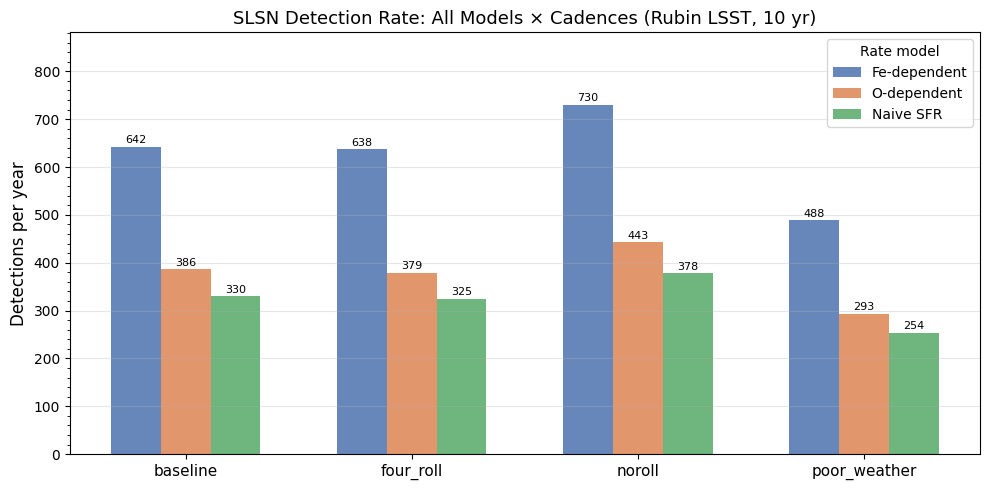

In [8]:
# ============================================================================
# CELL 4: Bar chart — detections/yr by cadence, grouped by model
# This is the main figure for Adam showing cadence × model comparison
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

cadence_order = ['baseline', 'four_roll', 'noroll', 'poor_weather']
model_order   = ['Fe-dependent', 'O-dependent', 'Naive SFR']
colors        = ['#4C72B0', '#DD8452', '#55A868']  # blue, orange, green

n_cadences = len(cadence_order)
n_models   = len(model_order)
width      = 0.22
x          = np.arange(n_cadences)

for i, (model_label, color) in enumerate(zip(model_order, colors)):
    vals = []
    for cad in cadence_order:
        row = detect_df[
            (detect_df['model_label'] == model_label) &
            (detect_df['cadence_short'] == cad)
        ]
        vals.append(row['per_year'].values[0] if len(row) else 0)
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=model_label, color=color, alpha=0.85)
    # Label each bar with its value
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                f'{v:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cadence_order, fontsize=11)
ax.set_ylabel('Detections per year', fontsize=12)
ax.set_title('SLSN Detection Rate: All Models × Cadences (Rubin LSST, 10 yr)', fontsize=13)
ax.legend(title='Rate model', fontsize=10)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)  # headroom for labels
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out_fig = get_output_dir('SLSNe') / f'multimodel_detections_per_yr_{DATE_TAG}.png'
plt.savefig(out_fig, dpi=150)
print(f'Saved: {out_fig.name}')
plt.show()

Saved: multimodel_ABC_metrics_all_cadences_260409.png


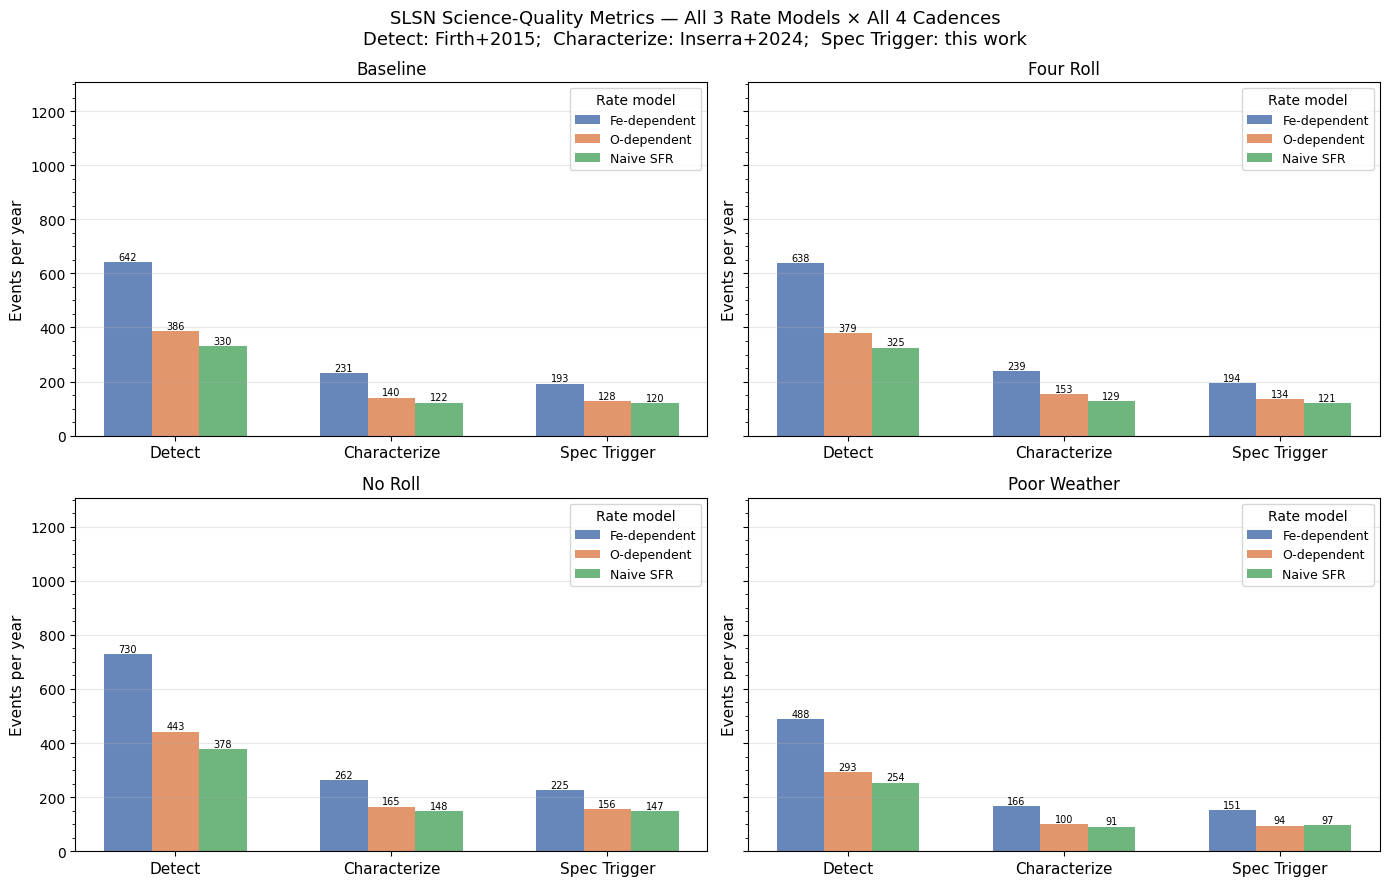

Saved: multimodel_VillarELAsTiCC_metrics_all_cadences_260409.png


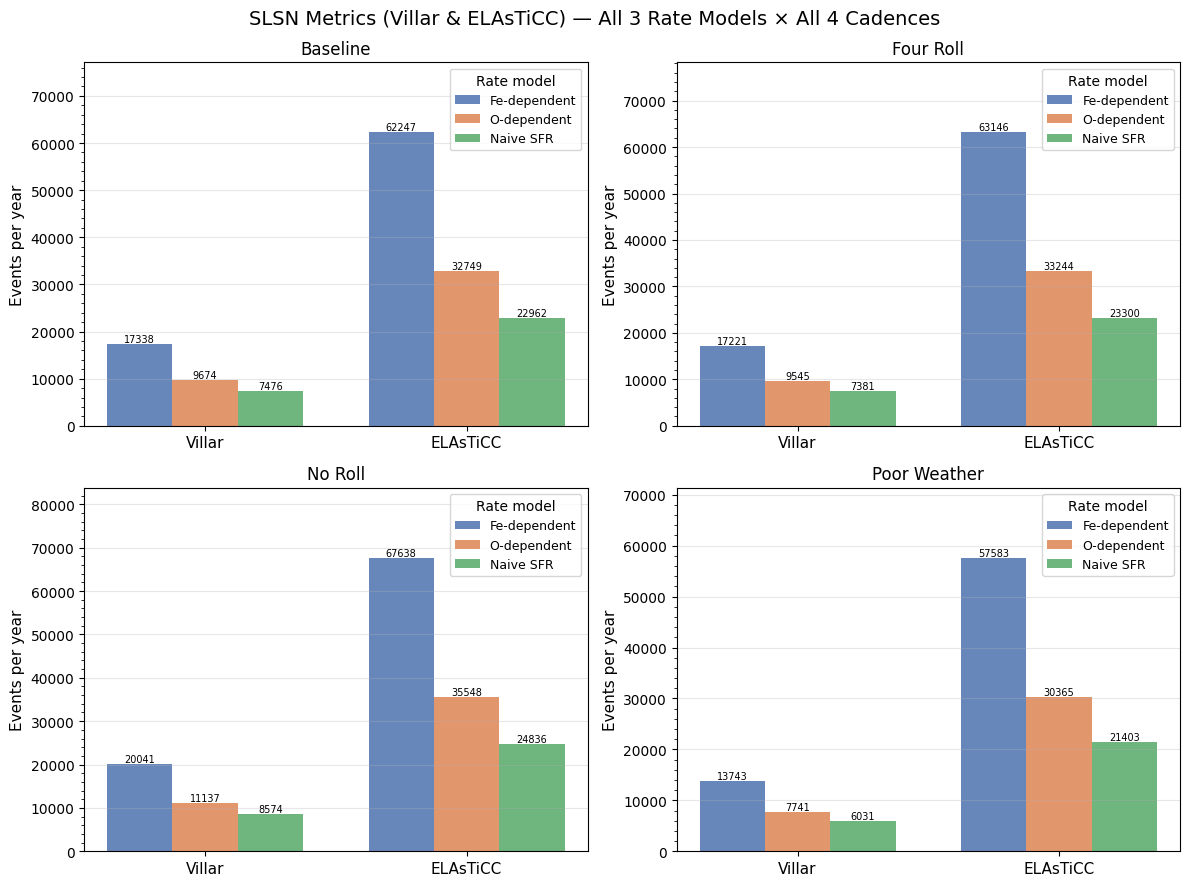

In [9]:
# ============================================================================
# CELL 5: Science-quality metrics — 2×2 cadence panels
# Split into two figures:
#   Figure A: Detect / Characterize / SpecTrigger  (sharey=True)
#   Figure B: Villar / ELAsTiCC                    (sharey=False)
# ============================================================================

# ── shared setup ─────────────────────────────────────────────────────────────
cadence_order_short = ['baseline', 'four_roll', 'noroll', 'poor_weather']
cadence_titles = {
    'baseline':     'Baseline',
    'four_roll':    'Four Roll',
    'noroll':       'No Roll',
    'poor_weather': 'Poor Weather',
}
colors_met = ['#4C72B0', '#DD8452', '#55A868']

# ── Figure A: Detect / Characterize / SpecTrigger ────────────────────────────
metric_map_A = {
    'SLSN_Detect_Metric':      'Detect',
    'SLSN_CharacterizeMetric': 'Characterize',
    'SLSN_SpecTriggerMetric':  'Spec Trigger',
}
metric_order_A  = list(metric_map_A.keys())
metric_labels_A = list(metric_map_A.values())

n_metrics_A = len(metric_order_A)
width_A     = 0.22
x_A         = np.arange(n_metrics_A)

fig_A, axes_A = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes_flat_A = axes_A.flatten()

for ax_idx, cadence_short in enumerate(cadence_order_short):
    ax = axes_flat_A[ax_idx]
    for i, (model, model_label, color) in enumerate(
        zip(MODELS, model_order, colors_met)
    ):
        vals = []
        for met in metric_order_A:
            row = df_all[
                (df_all['model']         == model) &
                (df_all['cadence_short'] == cadence_short) &
                (df_all['metric']        == met)
            ]
            vals.append(row['per_year'].values[0] if len(row) else 0)
        offset = (i - (n_models - 1) / 2) * width_A
        bars = ax.bar(x_A + offset, vals, width_A, label=model_label, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x_A)
    ax.set_xticklabels(metric_labels_A, fontsize=11)
    ax.set_ylabel('Events per year', fontsize=11)
    ax.set_title(cadence_titles[cadence_short], fontsize=12)
    ax.legend(title='Rate model', fontsize=9)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    ax.grid(axis='y', alpha=0.3)

fig_A.suptitle(
    'SLSN Science-Quality Metrics — All 3 Rate Models × All 4 Cadences\n'
    'Detect: Firth+2015;  Characterize: Inserra+2024;  Spec Trigger: this work',
    fontsize=13
)
plt.tight_layout()
out_figA = get_output_dir('SLSNe') / f'multimodel_ABC_metrics_all_cadences_{DATE_TAG}.png'
plt.savefig(out_figA, dpi=150)
print(f'Saved: {out_figA.name}')
plt.show()

# ── Figure B: Villar / ELAsTiCC ───────────────────────────────────────────────
metric_map_B = {
    'SLSN_VillarMetric':    'Villar',
    'SLSN_ELAsTiCC_Metric': 'ELAsTiCC',
}
metric_order_B  = list(metric_map_B.keys())
metric_labels_B = list(metric_map_B.values())

n_metrics_B = len(metric_order_B)
width_B     = 0.25
x_B         = np.arange(n_metrics_B)

fig_B, axes_B = plt.subplots(2, 2, figsize=(12, 9), sharey=False)
axes_flat_B = axes_B.flatten()

for ax_idx, cadence_short in enumerate(cadence_order_short):
    ax = axes_flat_B[ax_idx]
    for i, (model, model_label, color) in enumerate(
        zip(MODELS, model_order, colors_met)
    ):
        vals = []
        for met in metric_order_B:
            row = df_all[
                (df_all['model']         == model) &
                (df_all['cadence_short'] == cadence_short) &
                (df_all['metric']        == met)
            ]
            vals.append(row['per_year'].values[0] if len(row) else 0)
        offset = (i - (n_models - 1) / 2) * width_B
        bars = ax.bar(x_B + offset, vals, width_B, label=model_label, color=color, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x_B)
    ax.set_xticklabels(metric_labels_B, fontsize=11)
    ax.set_ylabel('Events per year', fontsize=11)
    ax.set_title(cadence_titles[cadence_short], fontsize=12)
    ax.legend(title='Rate model', fontsize=9)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
    ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
    ax.grid(axis='y', alpha=0.3)

fig_B.suptitle('SLSN Metrics (Villar & ELAsTiCC) — All 3 Rate Models × All 4 Cadences', fontsize=14)
plt.tight_layout()
out_figB = get_output_dir('SLSNe') / f'multimodel_VillarELAsTiCC_metrics_all_cadences_{DATE_TAG}.png'
plt.savefig(out_figB, dpi=150)
print(f'Saved: {out_figB.name}')
plt.show()


Saved: multimodel_eff_vs_z_baseline_v5_1_1_10yrs_260409.png


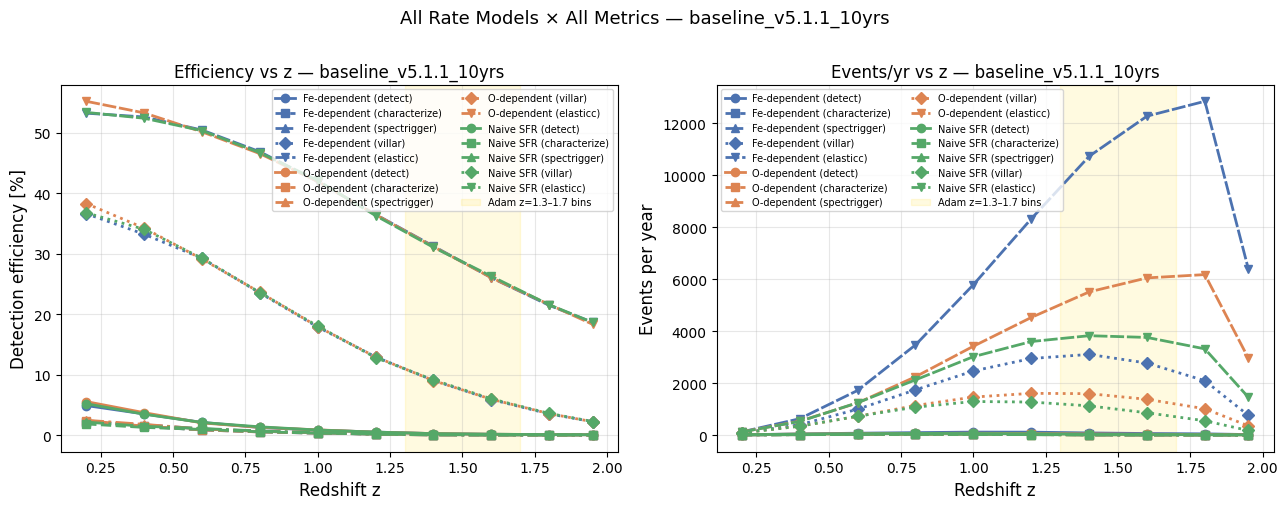

Saved: multimodel_eff_vs_z_four_roll_v5_0_0_10yrs_260409.png


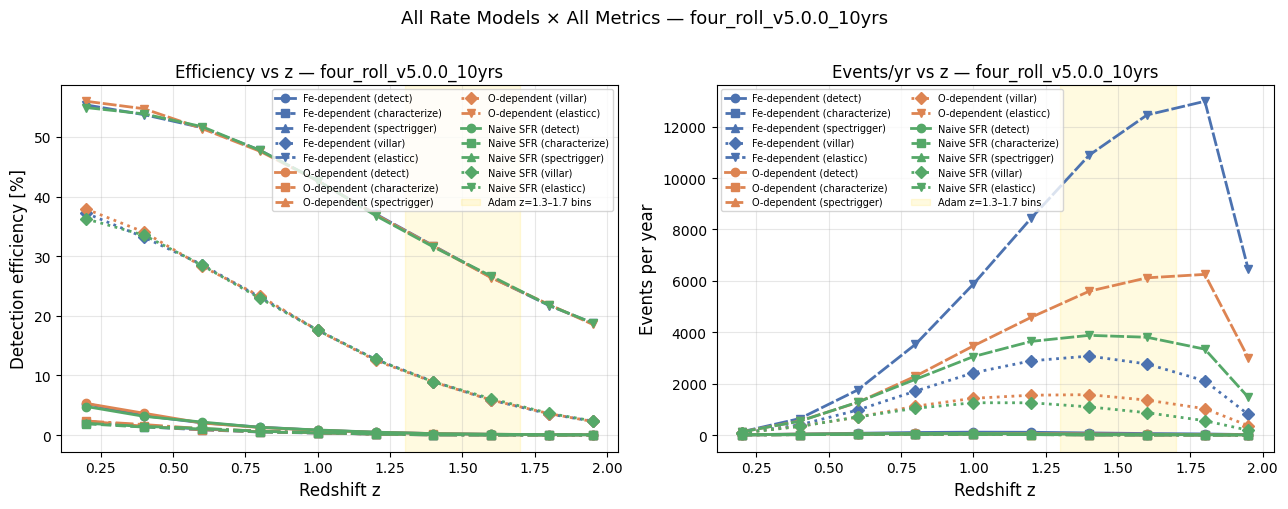

Saved: multimodel_eff_vs_z_noroll_v5_0_0_10yrs_260409.png


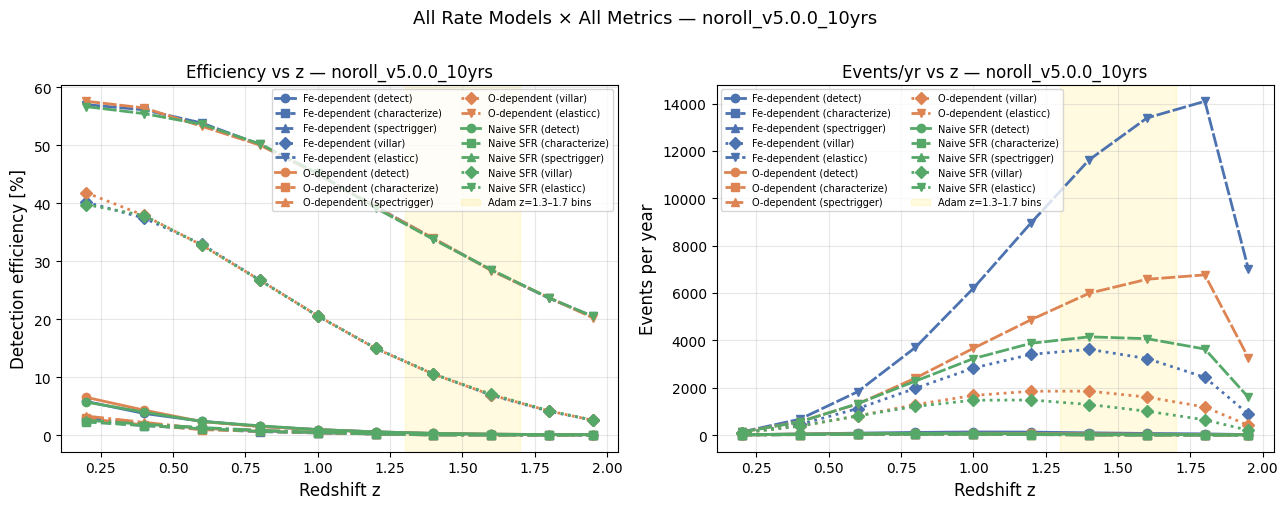

Saved: multimodel_eff_vs_z_poor_weather_v5_0_1_10yrs_260409.png


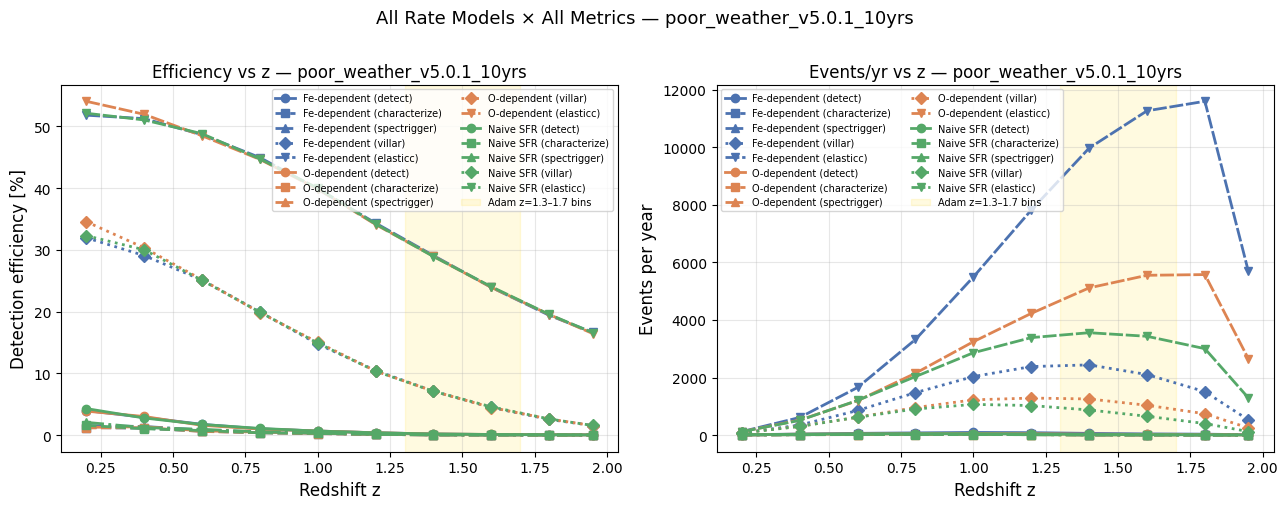

In [10]:
# ============================================================================
# CELL 7: Efficiency vs redshift bin — all 3 models × all cadences × all metrics
# One figure per cadence: efficiency [%] and events/yr vs z for all 5 metrics.
# Color encodes rate model; linestyle + marker encode metric.
# ============================================================================

# Redshift bins
z_edges = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.0])
z_centers = 0.5 * (z_edges[:-1] + z_edges[1:])

colors_model = {'fe_dependent': '#4C72B0', 'o_dependent': '#DD8452', 'naive': '#55A868'}

metric_keys_z = ['detect', 'characterize', 'spectrigger', 'villar', 'elasticc']
ls_metric = {
    'detect':       '-',
    'characterize': '--',
    'spectrigger':  '-.',
    'villar':       ':',
    'elasticc':     (0, (5, 1)),
}
markers_metric = {
    'detect':       'o',
    'characterize': 's',
    'spectrigger':  '^',
    'villar':       'D',
    'elasticc':     'v',
}

for cadence in CADENCES:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for model in MODELS:
        z_m = pop_data[model]['z']
        for metric in metric_keys_z:
            vals = pop_data[model][metric][cadence]
            if vals is None:
                print(f'  Skipping {model} / {metric} / {cadence} — no array')
                continue

            eff_bins   = []
            count_bins = []
            for z0, z1 in zip(z_edges[:-1], z_edges[1:]):
                mask = (z_m >= z0) & (z_m < z1)
                n_inj = mask.sum()
                n_det = vals[mask].sum()
                eff_bins.append(100 * n_det / n_inj if n_inj > 0 else np.nan)
                count_bins.append(n_det / SURVEY_YEARS)

            label = f'{model_labels[model]} ({metric})'
            axes[0].plot(z_centers, eff_bins,
                         marker=markers_metric[metric], color=colors_model[model],
                         ls=ls_metric[metric], lw=2, label=label)
            axes[1].plot(z_centers, count_bins,
                         marker=markers_metric[metric], color=colors_model[model],
                         ls=ls_metric[metric], lw=2, label=label)

    # Adam's bins — shade z=1.3–1.7
    for ax in axes:
        ax.axvspan(1.3, 1.7, alpha=0.12, color='gold', label='Adam z=1.3–1.7 bins')
        ax.set_xlabel('Redshift z', fontsize=12)
        ax.legend(fontsize=7, ncol=2)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Detection efficiency [%]', fontsize=12)
    axes[0].set_title(f'Efficiency vs z — {cadence}', fontsize=12)
    axes[1].set_ylabel('Events per year', fontsize=12)
    axes[1].set_title(f'Events/yr vs z — {cadence}', fontsize=12)

    cadence_slug = cadence.replace('.', '_')
    plt.suptitle(f'All Rate Models × All Metrics — {cadence}', fontsize=13, y=1.01)
    plt.tight_layout()
    out_fig = get_output_dir('SLSNe') / f'multimodel_eff_vs_z_{cadence_slug}_{DATE_TAG}.png'
    plt.savefig(out_fig, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_fig.name}')
    plt.show()


In [11]:
# ============================================================================
# CELL 8: Adam's fixed-z bins: z=1.2–1.8 and z=1.3–1.7
# All 3 models × all 4 cadences × all 5 metrics
# ============================================================================

# Two bin ranges Adam asked about
adam_bins = {
    'z=1.2\u20131.8': (1.2, 1.8),
    'z=1.3\u20131.7': (1.3, 1.7),
}

metric_keys_adam = ['detect', 'characterize', 'spectrigger', 'villar', 'elasticc']
metric_adam_labels = {
    'detect':       'Detect',
    'characterize': 'Characterize',
    'spectrigger':  'Spec Trigger',
    'villar':       'Villar',
    'elasticc':     'ELAsTiCC',
}

for bin_label, (z_lo, z_hi) in adam_bins.items():
    for metric in metric_keys_adam:
        print(f"\n{'='*65}")
        print(f"Adam's bin: {bin_label}  |  Metric: {metric_adam_labels[metric]}")
        print(f"{'='*65}")
        print(f"{'Model':<16} {'Cadence':<16} {'N injected':>12} "
              f"{'N detected':>12} {'Eff [%]':>9} {'SLSNe/yr':>10}")
        print('-' * 79)

        for model in MODELS:
            z_m = pop_data[model]['z']
            mask_z = (z_m >= z_lo) & (z_m <= z_hi)
            n_inj = mask_z.sum()

            for cadence in CADENCES:
                vals = pop_data[model][metric][cadence]
                if vals is None:
                    status = 'MISSING'
                    print(f'{model:<16} {cadence_labels[cadence]:<16} {n_inj:>12,} {status:>12}')
                    continue
                n_det = vals[mask_z].sum()
                eff   = 100 * n_det / n_inj if n_inj > 0 else 0
                per_yr = n_det / SURVEY_YEARS
                print(f'{model_labels[model]:<16} {cadence_labels[cadence]:<16} '
                      f'{n_inj:>12,} {n_det:>12,} {eff:>8.3f}% {per_yr:>9.1f}')
            print()   # blank line between models



Adam's bin: z=1.2–1.8  |  Metric: Detect
Model            Cadence            N injected   N detected   Eff [%]   SLSNe/yr
-------------------------------------------------------------------------------
Fe-dependent     baseline            1,224,874        2,178    0.178%     217.8
Fe-dependent     four_roll           1,224,874        2,153    0.176%     215.3
Fe-dependent     noroll              1,224,874        2,435    0.199%     243.5
Fe-dependent     poor_weather        1,224,874        1,518    0.124%     151.8

O-dependent      baseline              612,812        1,130    0.184%     113.0
O-dependent      four_roll             612,812        1,128    0.184%     112.8
O-dependent      noroll                612,812        1,308    0.213%     130.8
O-dependent      poor_weather          612,812          838    0.137%      83.8

Naive SFR        baseline              394,684          759    0.192%      75.9
Naive SFR        four_roll             394,684          757    0.192%      


--- fe_dependent x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_fe_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_baseline_v5.1.1_10yrs_260409.png


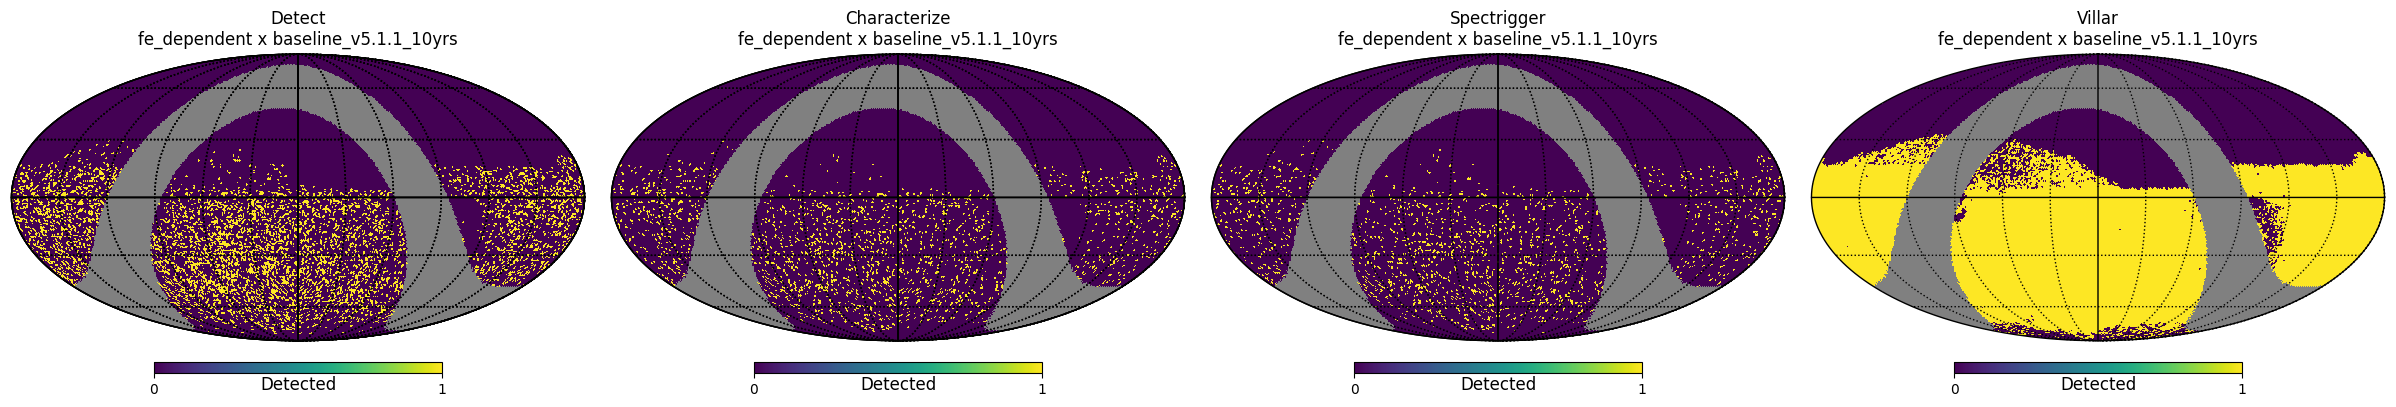

  Saved row: healpix_row_fe_dependent_baseline_v5.1.1_10yrs_260409.png

--- fe_dependent x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_fe_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_four_roll_v5.0.0_10yrs_260409.png


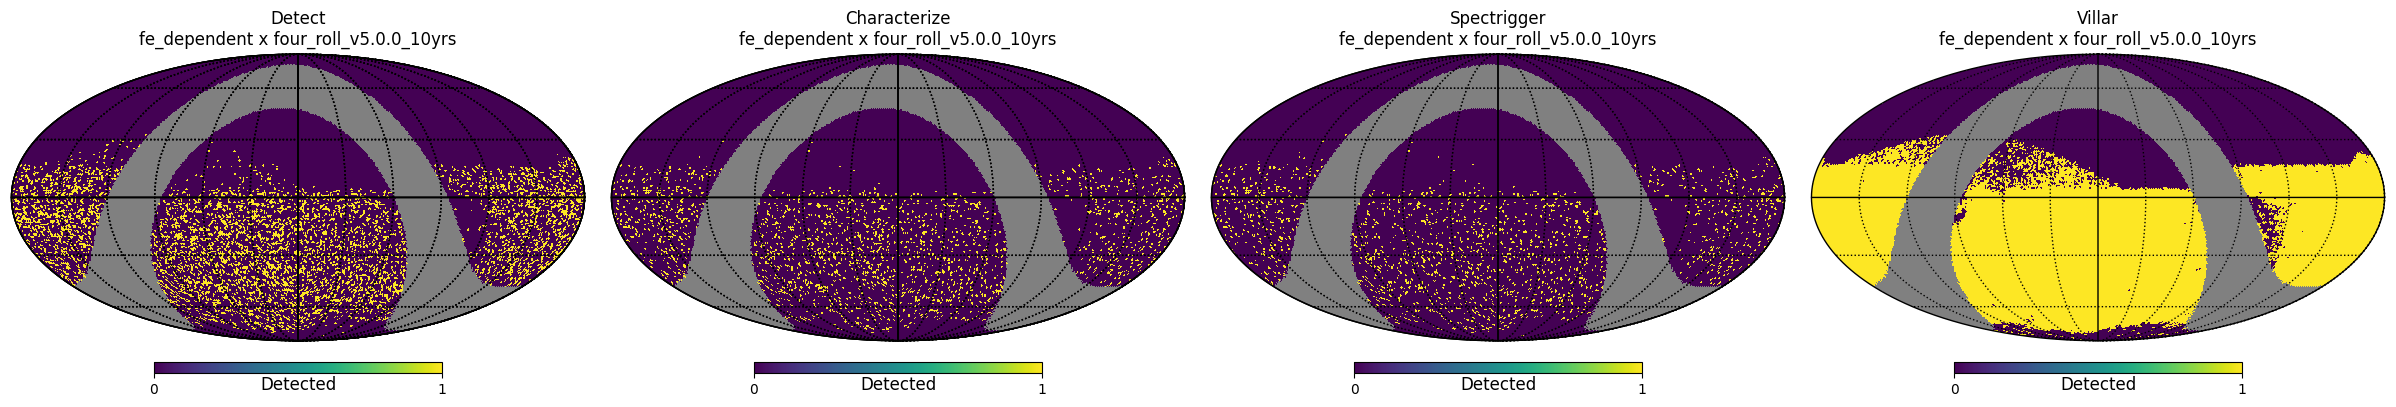

  Saved row: healpix_row_fe_dependent_four_roll_v5.0.0_10yrs_260409.png

--- fe_dependent x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_fe_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_noroll_v5.0.0_10yrs_260409.png


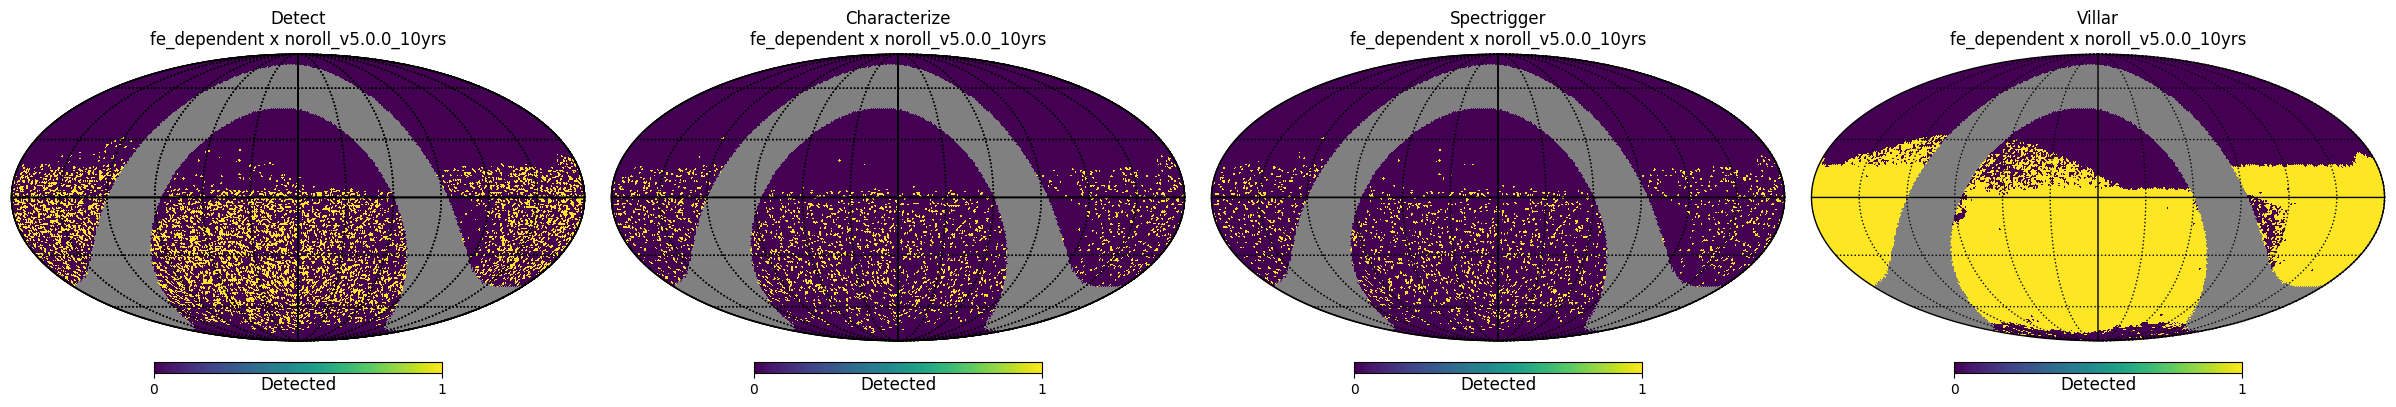

  Saved row: healpix_row_fe_dependent_noroll_v5.0.0_10yrs_260409.png

--- fe_dependent x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_characterize_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_spectrigger_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_villar_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png


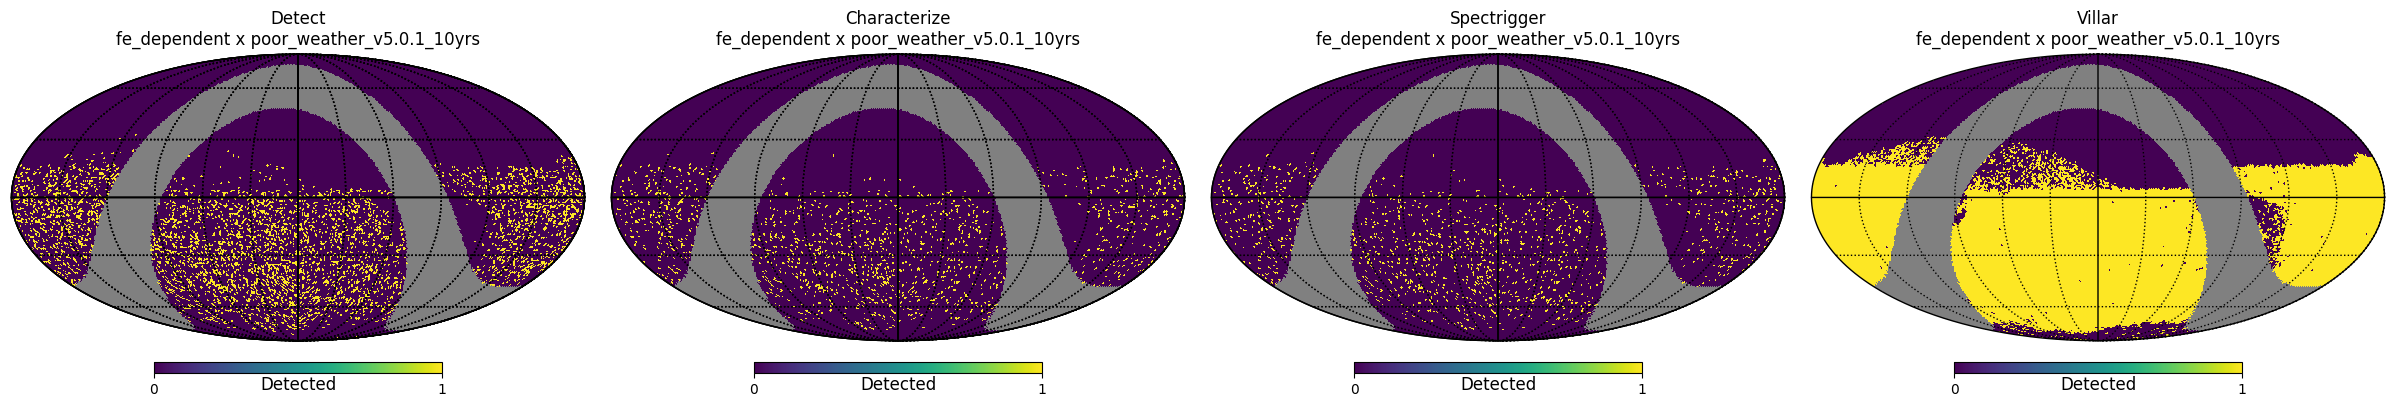

  Saved row: healpix_row_fe_dependent_poor_weather_v5.0.1_10yrs_260409.png

--- o_dependent x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_o_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_villar_o_dependent_baseline_v5.1.1_10yrs_260409.png


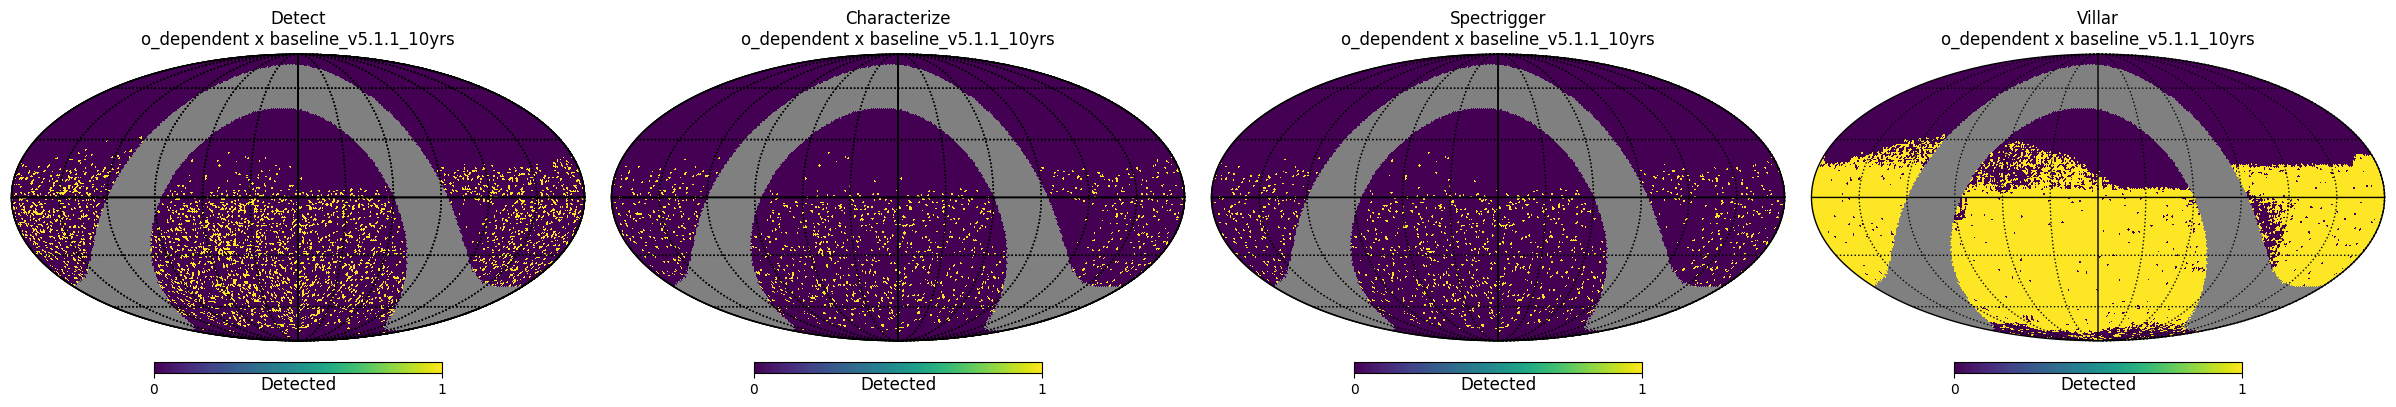

  Saved row: healpix_row_o_dependent_baseline_v5.1.1_10yrs_260409.png

--- o_dependent x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_o_dependent_four_roll_v5.0.0_10yrs_260409.png


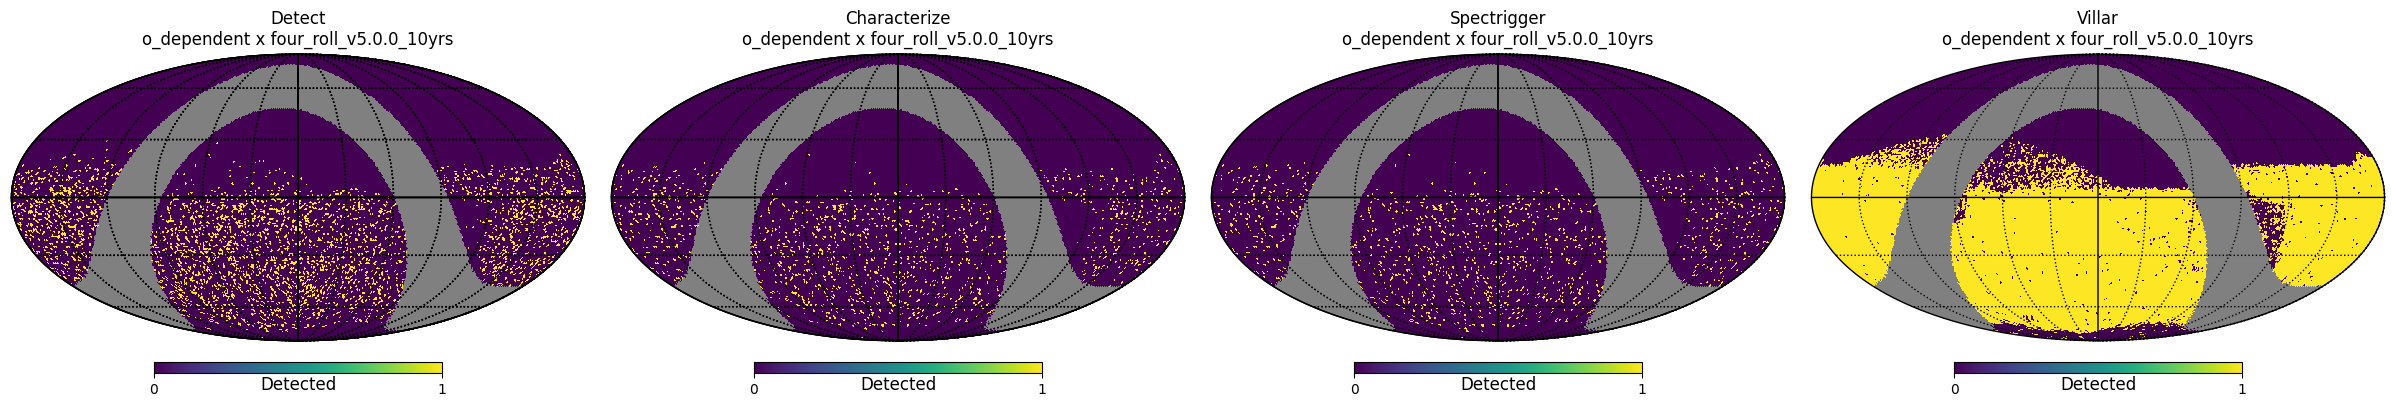

  Saved row: healpix_row_o_dependent_four_roll_v5.0.0_10yrs_260409.png

--- o_dependent x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_o_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_o_dependent_noroll_v5.0.0_10yrs_260409.png


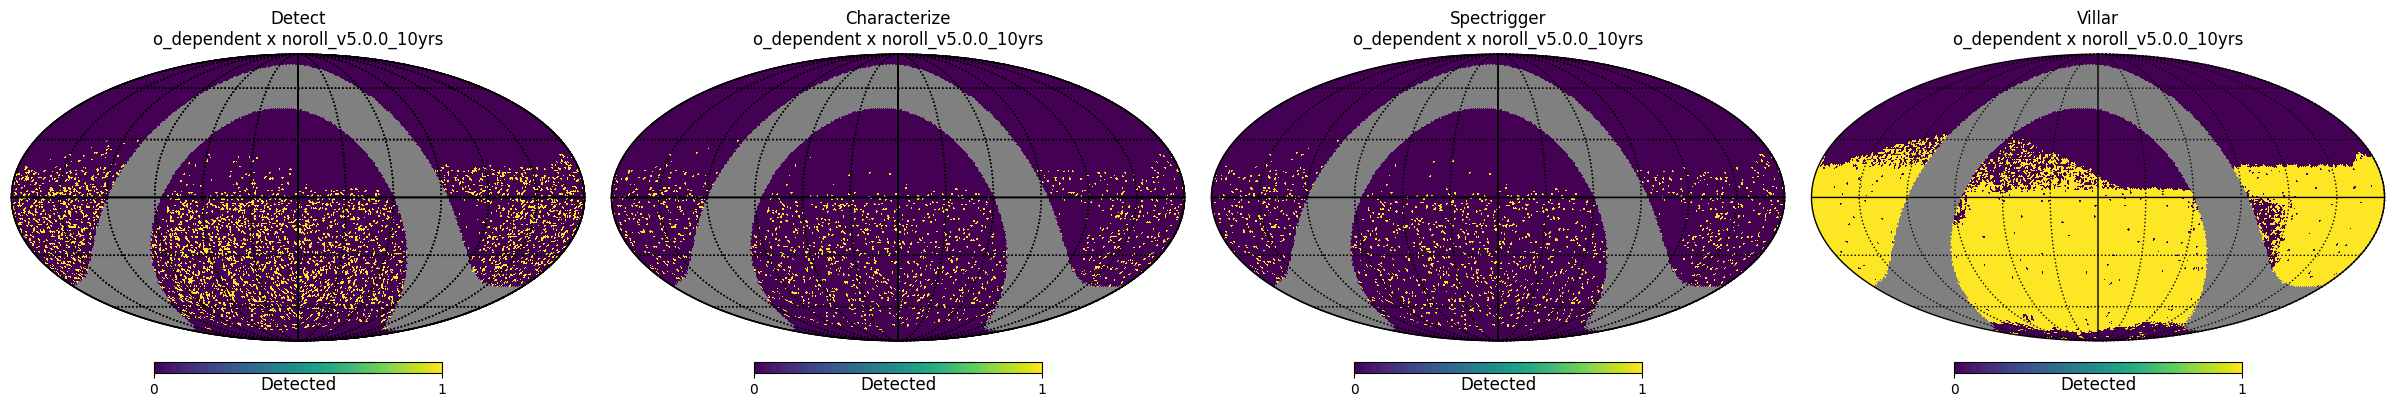

  Saved row: healpix_row_o_dependent_noroll_v5.0.0_10yrs_260409.png

--- o_dependent x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_o_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_characterize_o_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_spectrigger_o_dependent_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_villar_o_dependent_poor_weather_v5.0.1_10yrs_260409.png


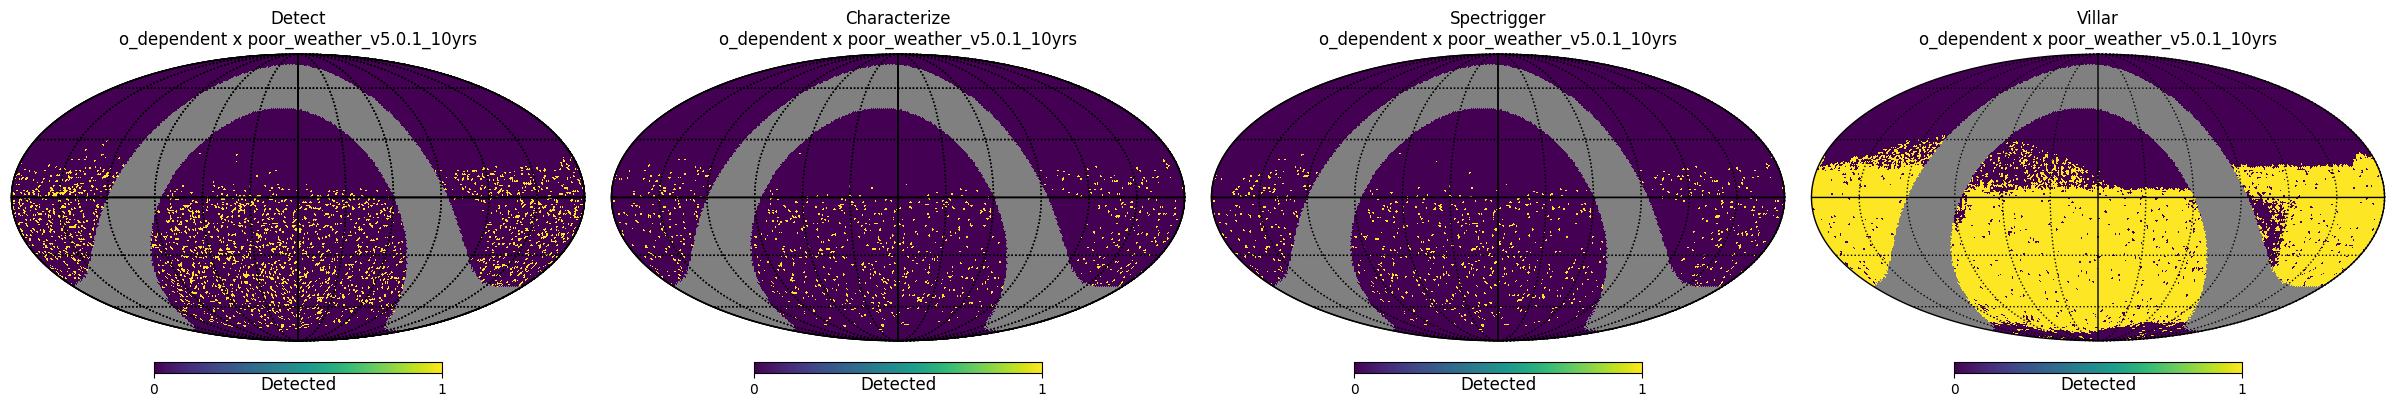

  Saved row: healpix_row_o_dependent_poor_weather_v5.0.1_10yrs_260409.png

--- naive x baseline_v5.1.1_10yrs ---
  Saved: healpix_detect_naive_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_characterize_naive_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_spectrigger_naive_baseline_v5.1.1_10yrs_260409.png
  Saved: healpix_villar_naive_baseline_v5.1.1_10yrs_260409.png


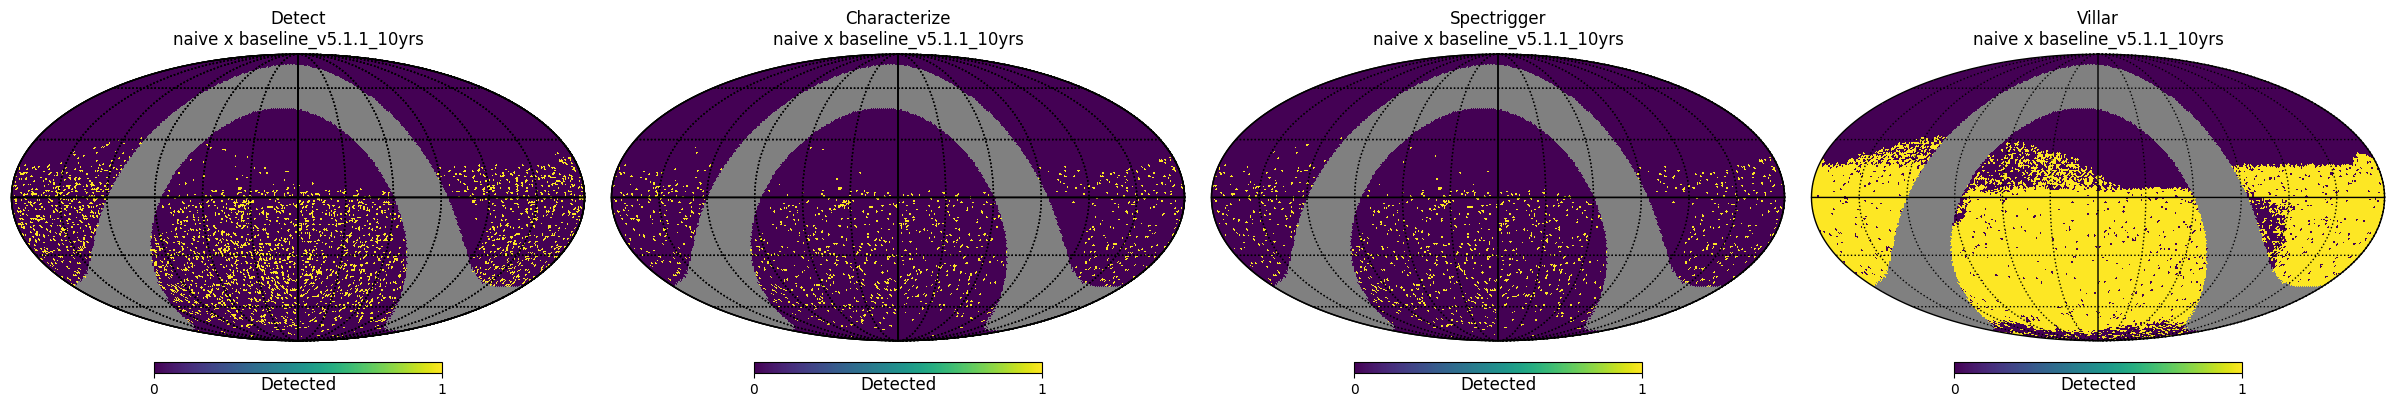

  Saved row: healpix_row_naive_baseline_v5.1.1_10yrs_260409.png

--- naive x four_roll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_naive_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_naive_four_roll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_naive_four_roll_v5.0.0_10yrs_260409.png


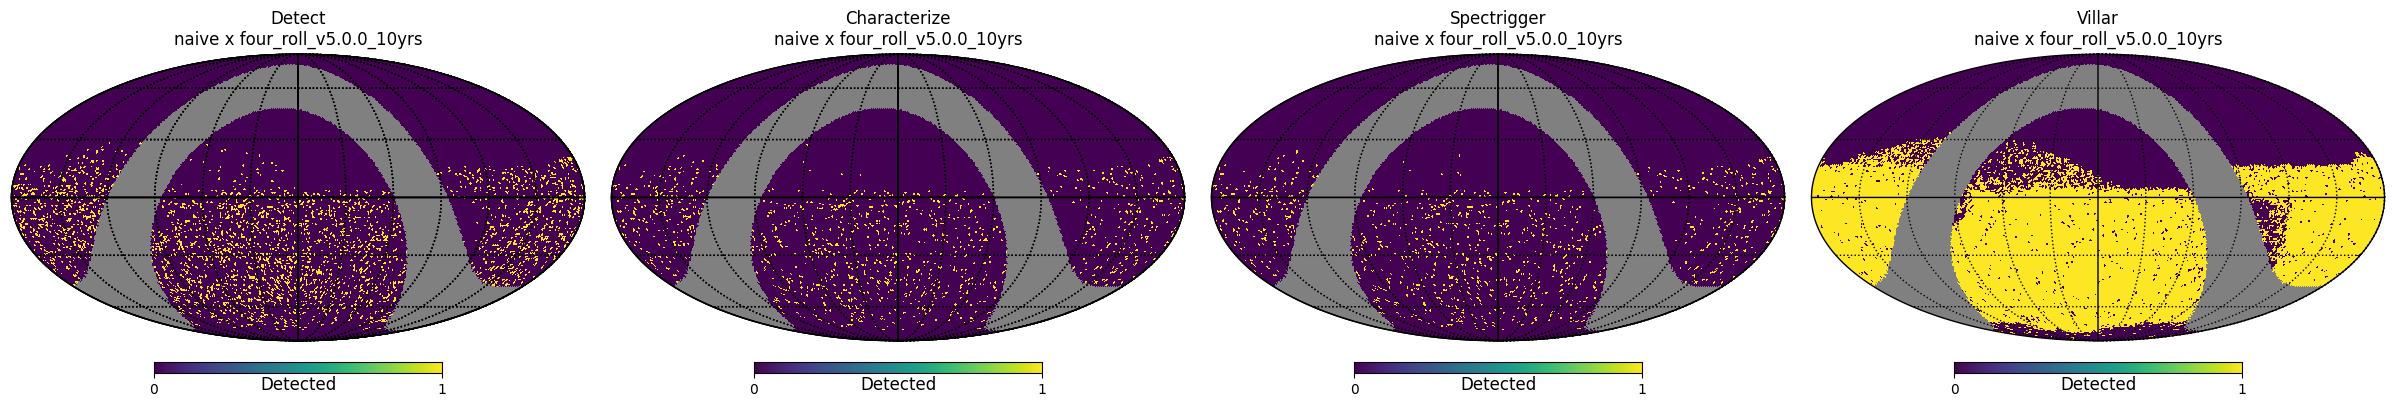

  Saved row: healpix_row_naive_four_roll_v5.0.0_10yrs_260409.png

--- naive x noroll_v5.0.0_10yrs ---
  Saved: healpix_detect_naive_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_characterize_naive_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_spectrigger_naive_noroll_v5.0.0_10yrs_260409.png
  Saved: healpix_villar_naive_noroll_v5.0.0_10yrs_260409.png


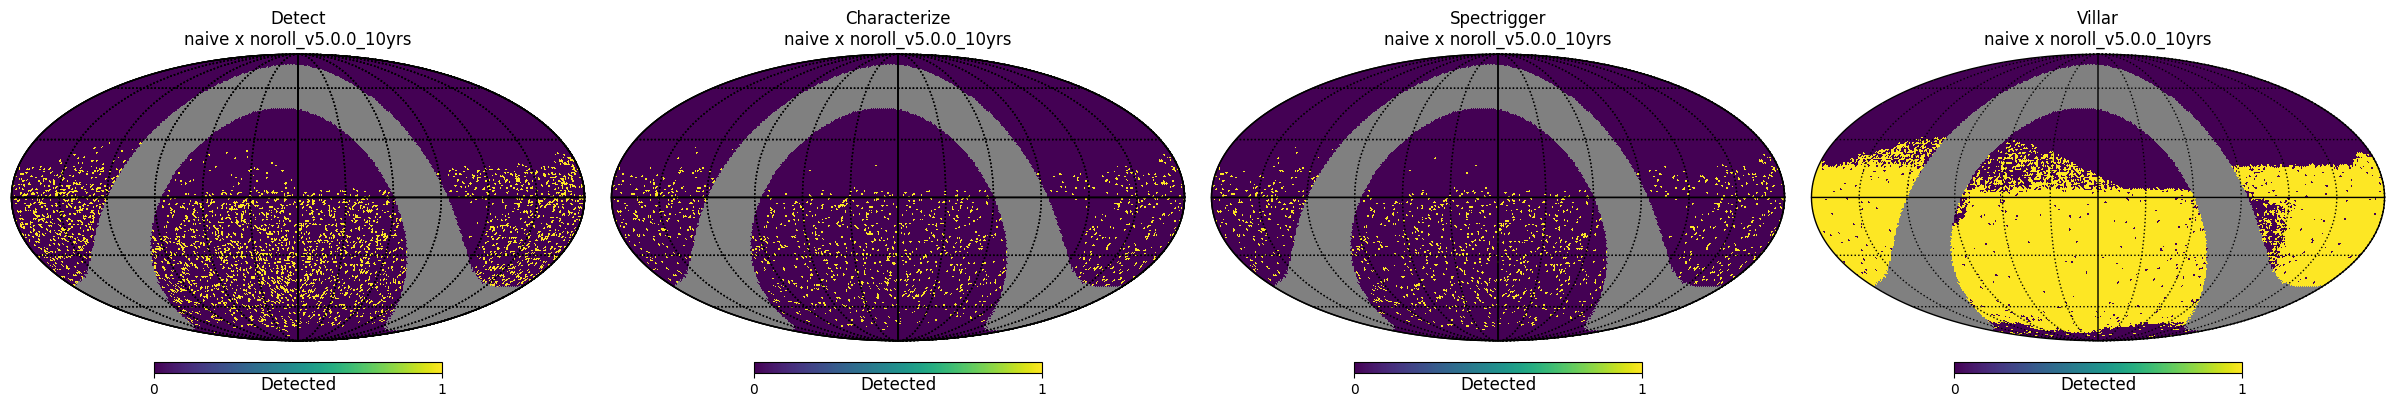

  Saved row: healpix_row_naive_noroll_v5.0.0_10yrs_260409.png

--- naive x poor_weather_v5.0.1_10yrs ---
  Saved: healpix_detect_naive_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_characterize_naive_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_spectrigger_naive_poor_weather_v5.0.1_10yrs_260409.png
  Saved: healpix_villar_naive_poor_weather_v5.0.1_10yrs_260409.png


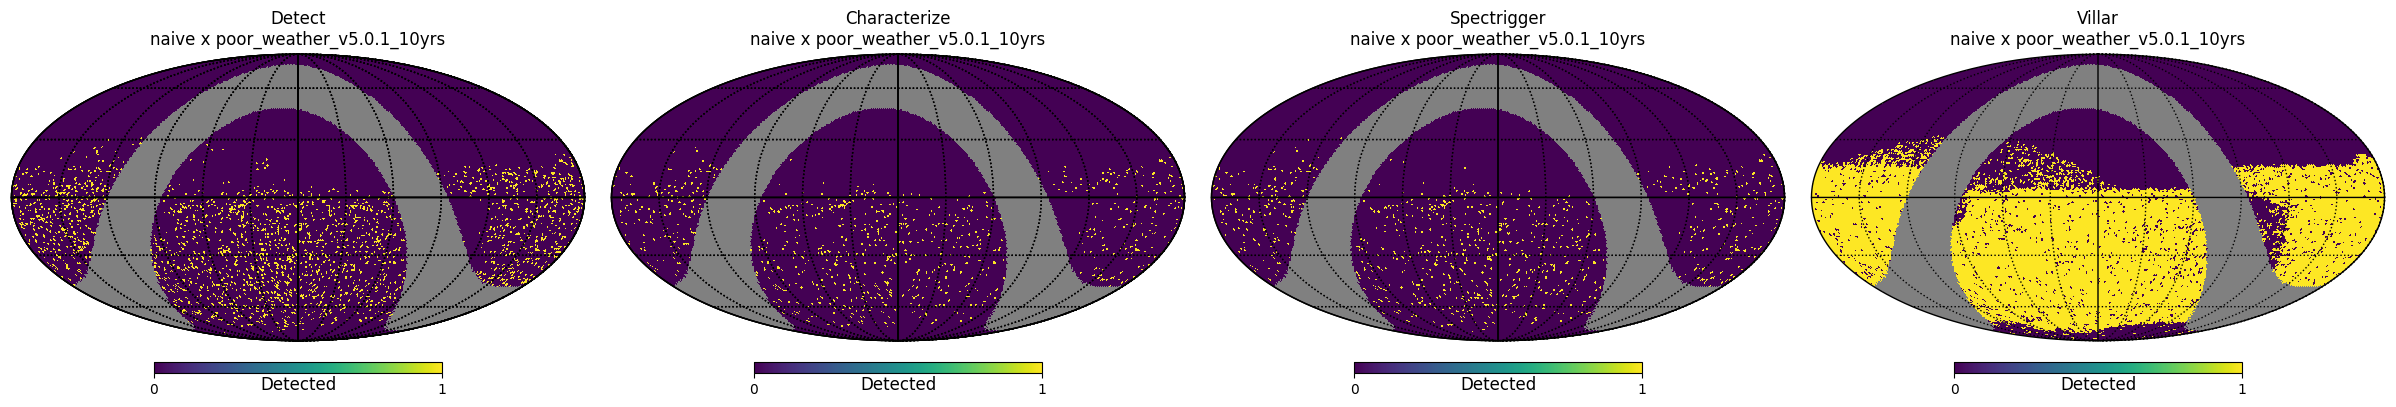

  Saved row: healpix_row_naive_poor_weather_v5.0.1_10yrs_260409.png


In [12]:
# ============================================================================
# CELL 9: HEALPix sky maps — all 3 models × all 4 cadences
# Each cadence = one row of 4 maps (detect, characterize, spectrigger, villar)
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_healpix_efficiency

METRIC_KEYS = ["detect", "characterize", "spectrigger", "villar"]
HEALPIX_FIGSIZE = (24, 4)  # ← width × height per cadence row

for model in MODELS:
    ra_map  = pop_data[model]["ra"]
    dec_map = pop_data[model]["dec"]

    for cadence in CADENCES:
        print(f"\n--- {model} x {cadence} ---")

        # One figure per cadence, 4 subplots side by side
        fig = plt.figure(figsize=HEALPIX_FIGSIZE)

        for col_idx, metric in enumerate(METRIC_KEYS):
            metric_map = pop_data[model][metric][cadence]
            if metric_map is None:
                print(f"  Skipping {metric} — array missing")
                continue

            # Build healpix map
            import healpy as hp
            npix = hp.nside2npix(64)
            injected_map = np.zeros(npix)
            detected_map = np.zeros(npix)
            theta = 0.5 * np.pi - dec_map
            pix   = hp.ang2pix(64, theta, ra_map)
            for i, p in enumerate(pix):
                injected_map[p] += 1
                if int(metric_map[i]) == 1:
                    detected_map[p] += 1
            eff = np.full(npix, hp.UNSEEN)
            mask = injected_map > 0
            eff[mask] = (detected_map[mask] > 0).astype(float)

            # Plot into subplot
            hp.mollview(
                eff,
                title  = f"{metric.capitalize()}\n{model} x {cadence}",
                unit   = 'Detected',
                cmap   = 'viridis',
                min    = 0, max = 1,
                hold   = False,
                sub    = (1, len(METRIC_KEYS), col_idx + 1),
                fig    = fig.number
            )
            hp.graticule()

            # Save individual file too
            out_healpix = get_output_dir("SLSNe", subdir=model) / \
                          f"healpix_{metric}_{model}_{cadence}_{DATE_TAG}.png"
            print(f"  Saved: {out_healpix.name}")

        # Save the combined row figure
        out_row = get_output_dir("SLSNe", subdir=model) / \
                  f"healpix_row_{model}_{cadence}_{DATE_TAG}.png"
        plt.savefig(str(out_row), dpi=150, bbox_inches='tight')
        plt.show()
        plt.close()
        print(f"  Saved row: {out_row.name}")


=== plot_sky_detection: Fe-dependent x baseline_v5.1.1_10yrs ===


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2217: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2219: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_dir / f"diag_ra_vs_mag_{filtername}.png", dpi=150)
/users/1/andra104/.conda/envs/rubin_sim_2.6.1/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


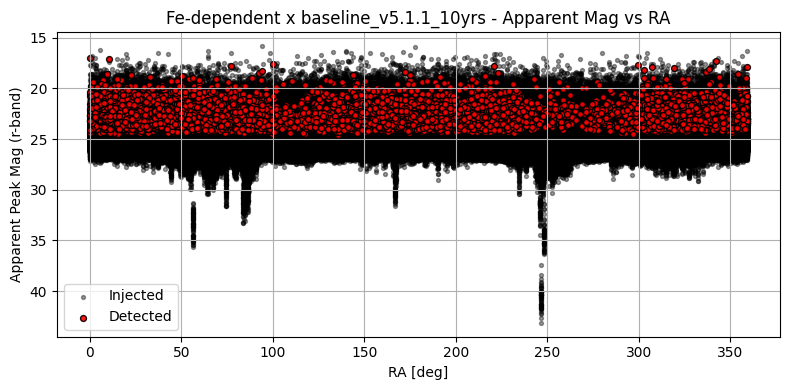

/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2230: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:2232: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_dir / f"diag_dec_vs_mag_{filtername}.png", dpi=150)


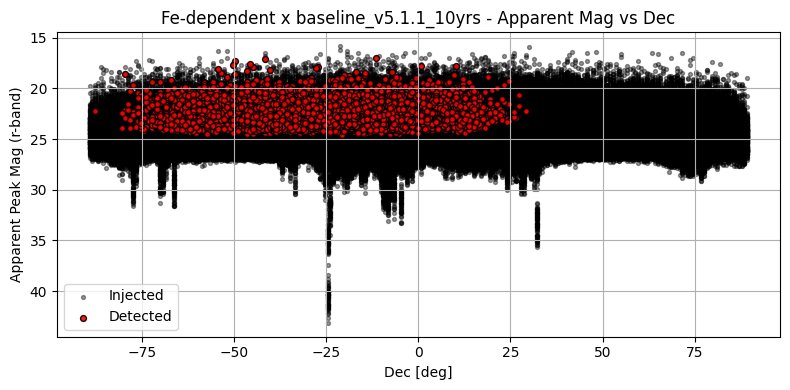

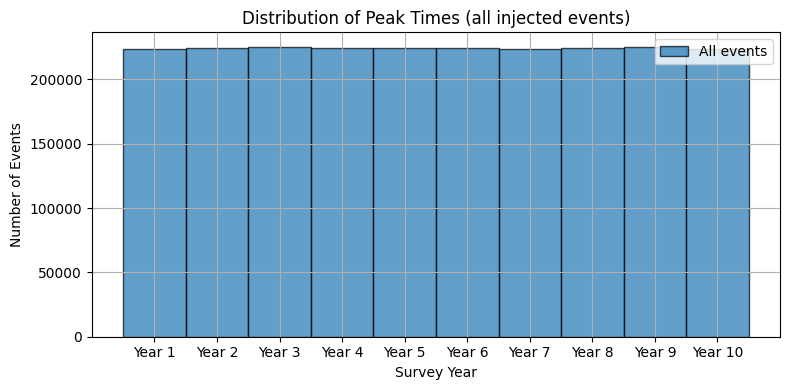

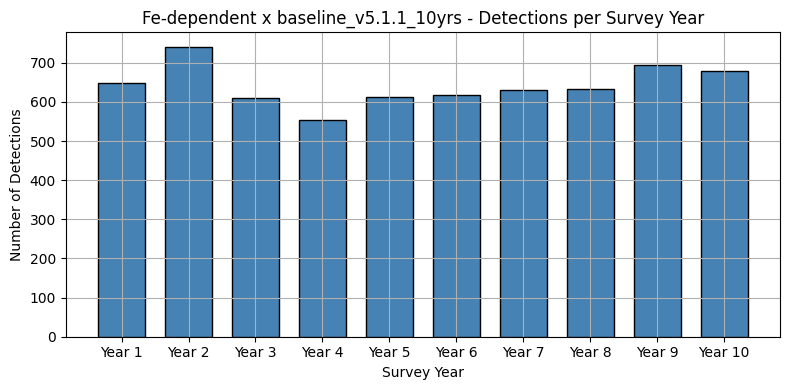

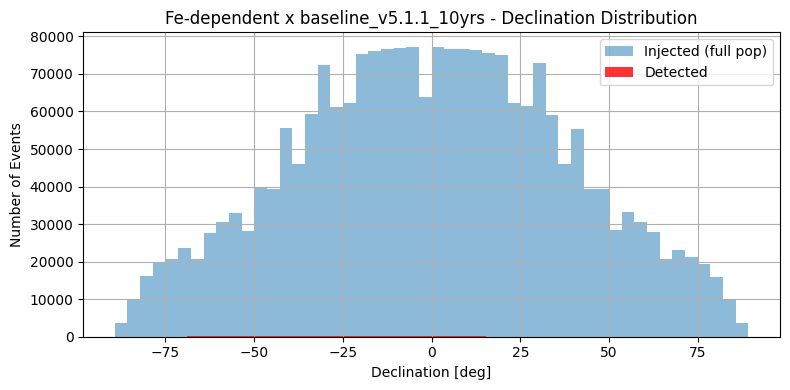


=== plot_sky_detection: O-dependent x baseline_v5.1.1_10yrs ===


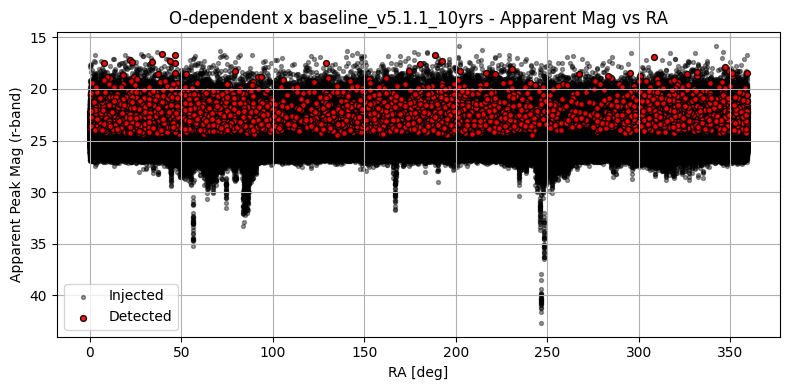

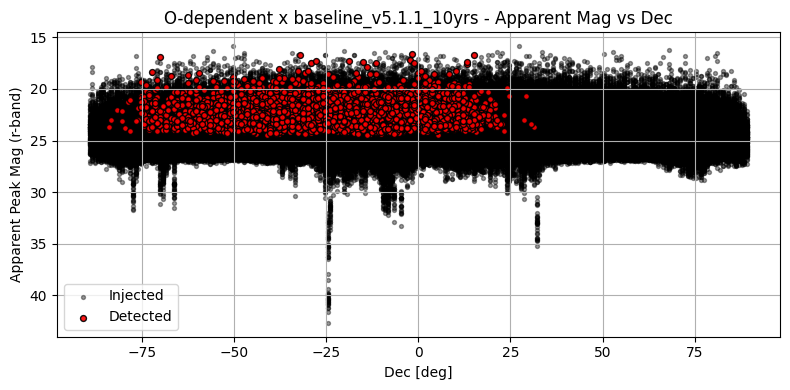

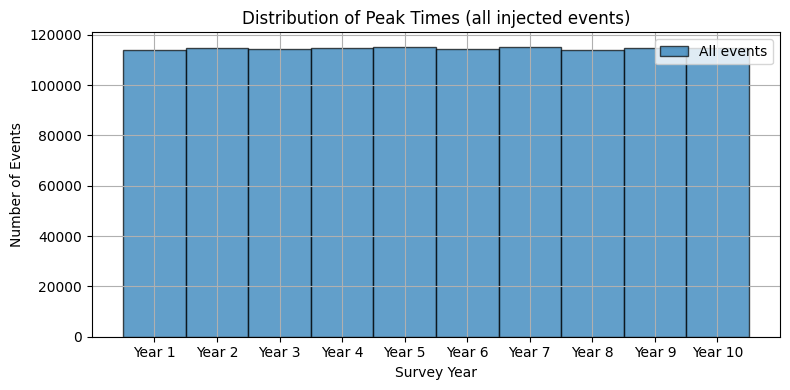

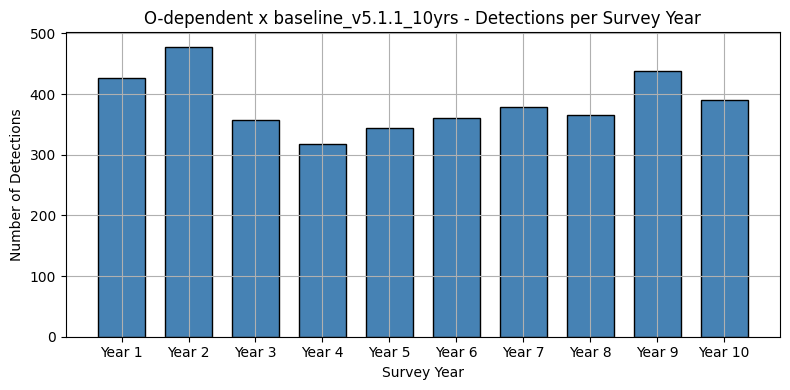

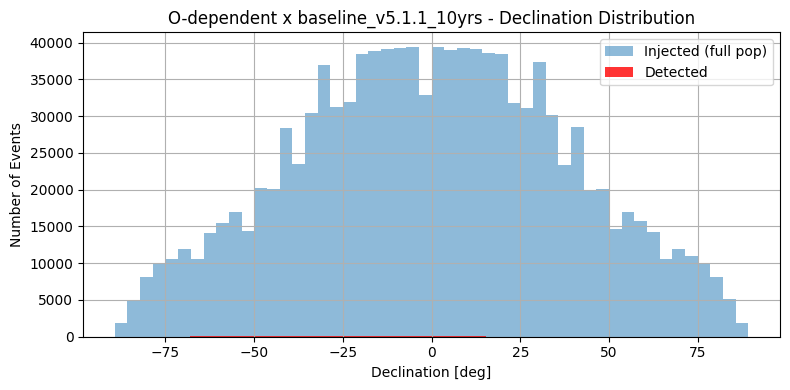


=== plot_sky_detection: Naive SFR x baseline_v5.1.1_10yrs ===


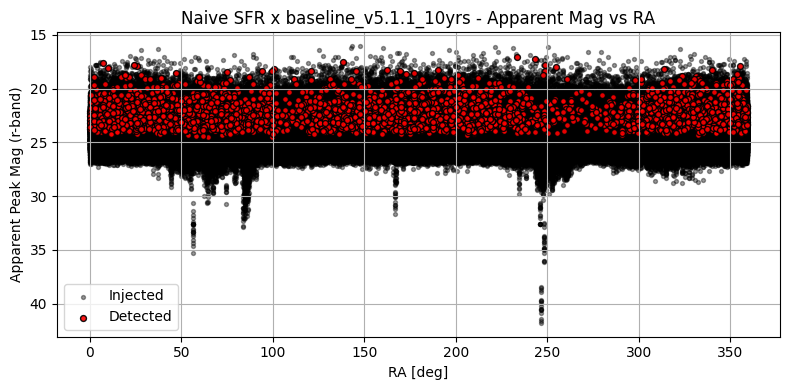

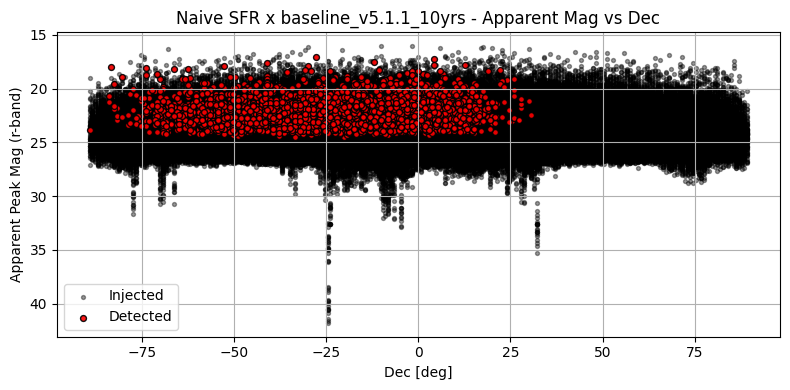

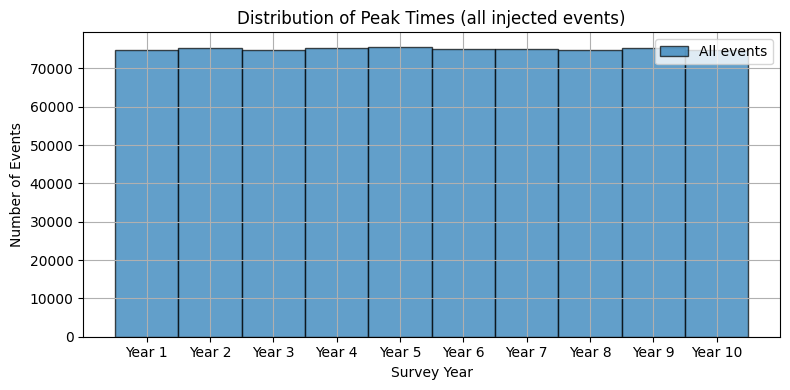

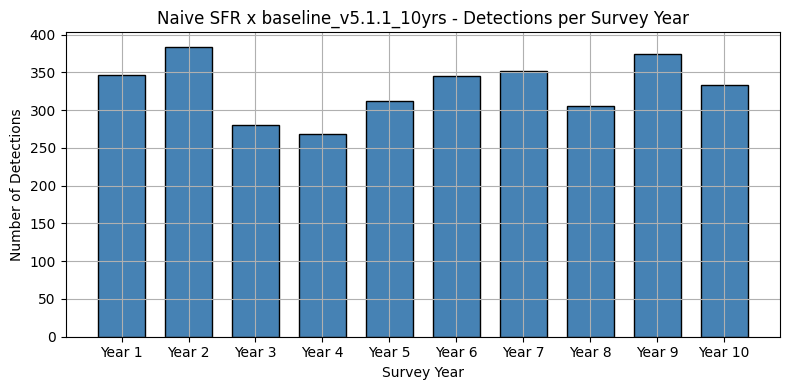

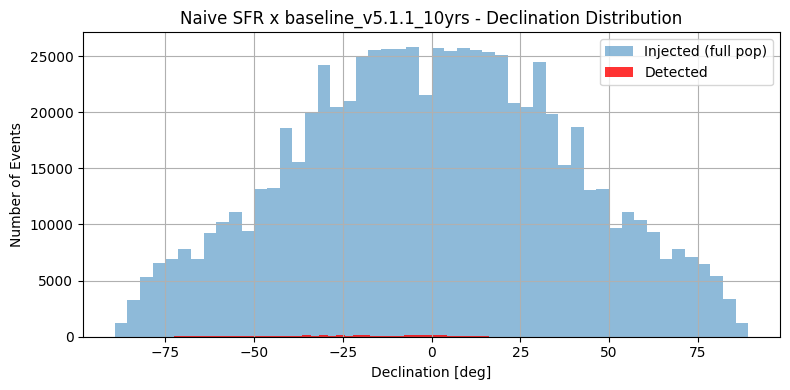

In [13]:
# ============================================================================
# CELL D: Sky detection diagnostic — all 3 models × baseline cadence
# Produces 5 plots per call: RA vs mag, Dec vs mag, peak-time dist,
# detections/yr, dec distribution (injected vs detected).
# df_obs built from pop_slicers[model].slice_points + detect .npy arrays.
# sp['sid'] = np.arange(n_events) — confirmed present in all 3 pickles.
# Uses baseline as representative cadence; change CADENCE_SKY to zoom in.
# ============================================================================
reload(diag_mod)
from slsn_metrics.diagnostics import plot_sky_detection

CADENCE_SKY = 'baseline_v5.1.1_10yrs'

for model in MODELS:
    print(f'\n=== plot_sky_detection: {model_labels[model]} x {CADENCE_SKY} ===')
    model_dir  = get_output_dir('SLSNe', subdir=model)
    detect_arr = pop_data[model]['detect'][CADENCE_SKY]
    if detect_arr is None:
        print(f'  Skipping — no detect array for {CADENCE_SKY}')
        continue

    sp = pop_slicers[model].slice_points
    df_obs = pd.DataFrame({
        'sid':       sp['sid'].astype(int),
        'detected':  detect_arr.astype(bool),
        'peak_time': sp['peak_time'],
    })

    plot_sky_detection(
        df_obs            = df_obs,
        population_slicer = pop_slicers[model],
        mjd0              = MJD0,
        filtername        = 'r',
        cadence_name      = f'{model_labels[model]} x {CADENCE_SKY}',
        save_dir          = model_dir,
    )


=== baseline_v5.1.1_10yrs | detect ===


  Saved: mc_panel_3panel_detect_baseline_v5.1.1_10yrs.png


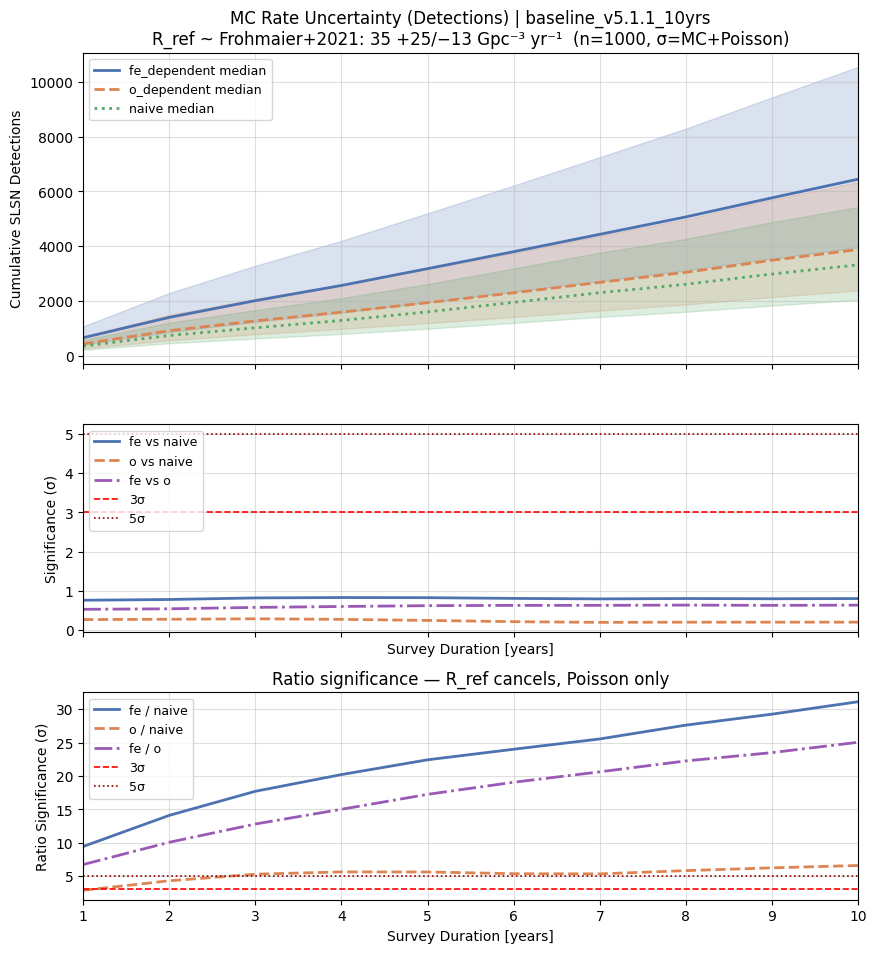


=== four_roll_v5.0.0_10yrs | detect ===
  Saved: mc_panel_3panel_detect_four_roll_v5.0.0_10yrs.png


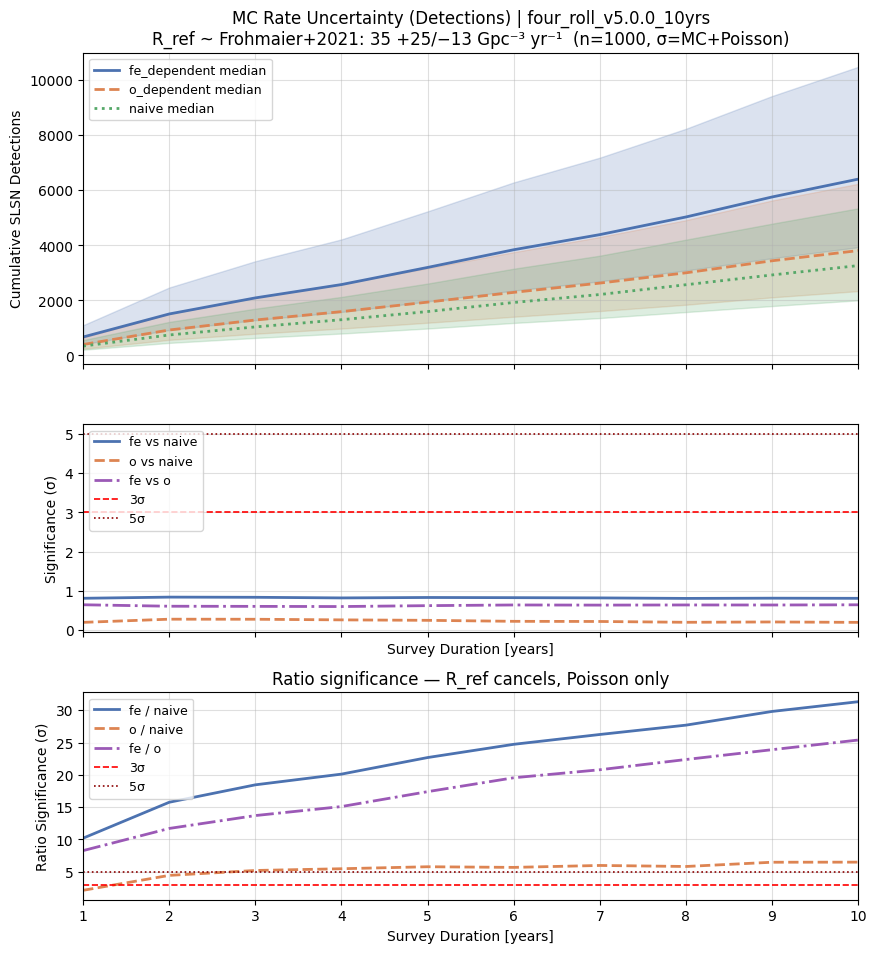


=== noroll_v5.0.0_10yrs | detect ===
  Saved: mc_panel_3panel_detect_noroll_v5.0.0_10yrs.png


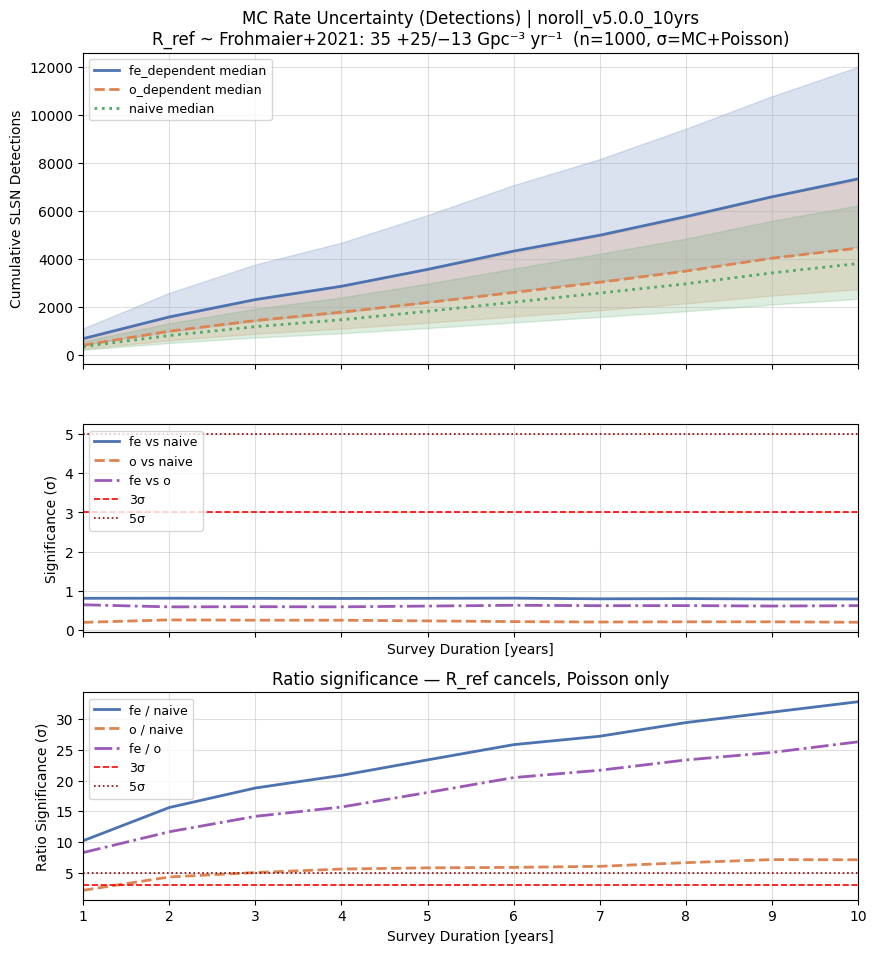


=== poor_weather_v5.0.1_10yrs | detect ===
  Saved: mc_panel_3panel_detect_poor_weather_v5.0.1_10yrs.png


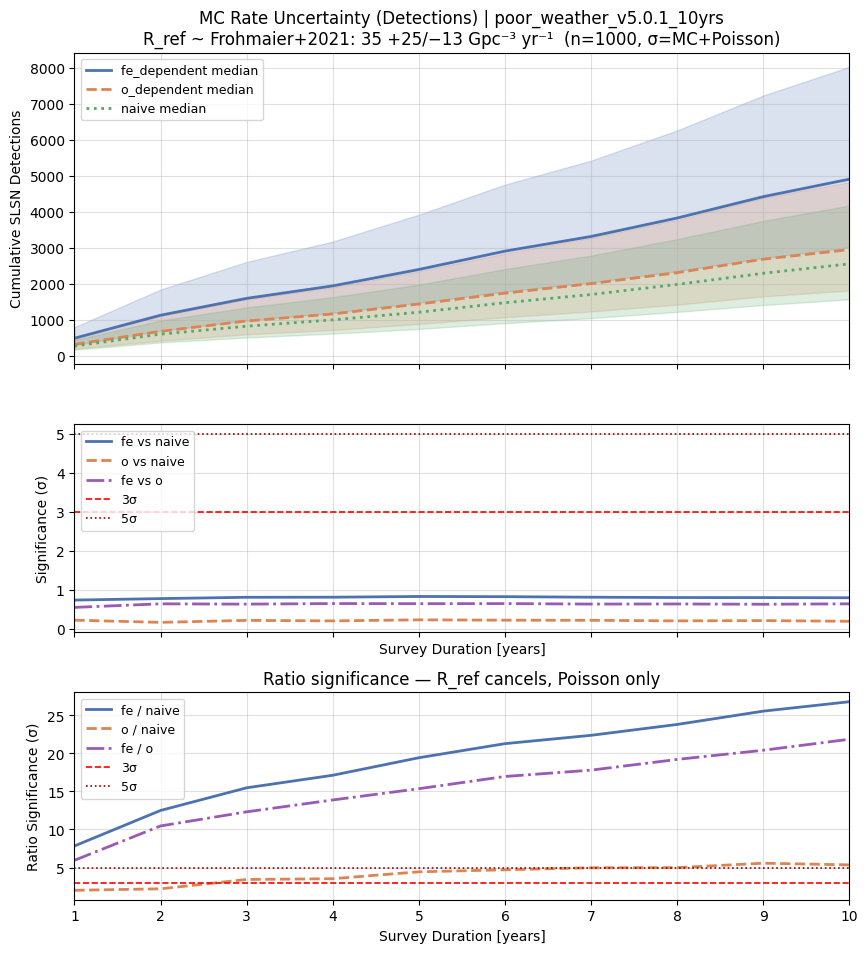

In [16]:
# ============================================================================
# CELL 10 - MC: Monte Carlo rate uncertainty — all cadences, all models
# ============================================================================
# Reload flags:
#   Templates  : NO
#   Population : NO — peak_time already in pop_data from Cell 6
#   Mag grid   : NO
#   Kernel     : NO
#
# Toggle METRIC_KEY to switch which detection stage is plotted.
# Produces one figure per cadence, each with:
#   Top    : N(SLSNe) — all 3 models with 68% CI bands
#   Bottom : Significance — fe vs naive, o vs naive, fe vs o
# ============================================================================

import slsn_metrics.diagnostics as diag_mod
from importlib import reload
reload(diag_mod)
from slsn_metrics.diagnostics import plot_mc_rate_uncertainty_panel

# --- Toggle this to switch metric ---
METRIC_KEY   = 'detect'        # options: 'detect', 'characterize', 'spectrigger'
                               # Note: 'villar' and 'elasticc' are not appropriate here —
                               # they encode photometric classifier scores, not detection
                               # counts, and cannot be interpreted as absolute rates.
METRIC_LABEL = {
    'detect':       'Detections',
    'characterize': 'Characterized',
    'spectrigger':  'Spec Triggers',
}[METRIC_KEY]

SAVE_DIR = get_output_dir('SLSNe', subdir='fe_dependent')

for cadence in CADENCES:
    print(f'\n=== {cadence} | {METRIC_KEY} ===')
    plot_mc_rate_uncertainty_panel(
        pop_data       = pop_data,
        cadence        = cadence,
        metric_key     = METRIC_KEY,
        metric_label   = METRIC_LABEL,
        R_ref_nominal  = 35.0,
        n_realizations = 1000,
        seed           = 42,
        save_dir       = SAVE_DIR,
    )

In [17]:
for model in MODELS:
    print(model, list(pop_data[model].keys()))

fe_dependent ['z', 'ra', 'dec', 'peak_time', 'detect', 'characterize', 'spectrigger', 'villar', 'elasticc']
o_dependent ['z', 'ra', 'dec', 'peak_time', 'detect', 'characterize', 'spectrigger', 'villar', 'elasticc']
naive ['z', 'ra', 'dec', 'peak_time', 'detect', 'characterize', 'spectrigger', 'villar', 'elasticc']


Total templates available: 261


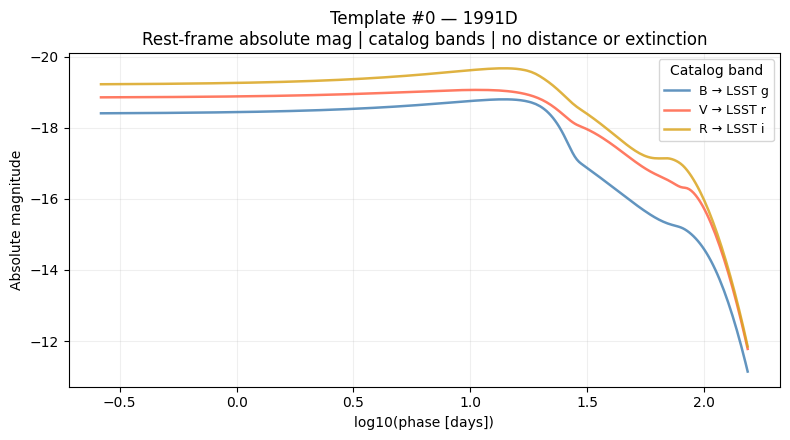

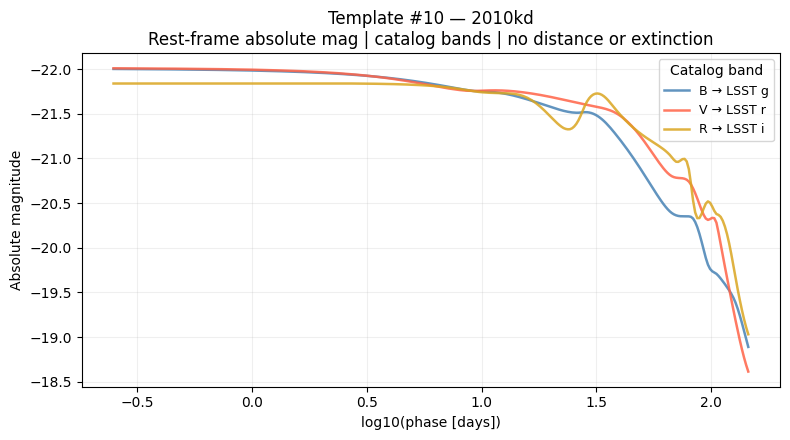

  template 50: no B/V/R bands


In [18]:
# ============================================================================
# CELL E: Template sampler — GP templates in absolute mag
# Shows intrinsic SLSN light curve shapes before distance or extinction.
# Templates are shared across all 3 models — run once.
# Reload flags: NO reloads needed.
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt

CATALOG_BANDS = ['B', 'V', 'R']
BAND_MAP      = {'B': 'g', 'V': 'r', 'R': 'i'}
CAT_COLORS    = {'B': 'steelblue', 'V': 'tomato', 'R': 'goldenrod'}
TEMPLATE_INDICES = [0, 10, 50]   # change to inspect specific templates
USE_LOG_TIME     = True

def _t_grid(tpl, use_log):
    all_ph = []
    for band in CATALOG_BANDS:
        if band not in tpl:
            continue
        ph = np.asarray(tpl[band]['ph'], dtype=float)
        ph = ph[np.isfinite(ph) & (ph > 0)]
        if ph.size:
            all_ph.append(ph)
    if not all_ph:
        return np.array([]), np.array([])
    ph_all = np.concatenate(all_ph)
    t0, t1 = ph_all.min(), ph_all.max()
    t_eval = np.geomspace(max(t0, 0.1), t1, 300)
    t_plot = np.log10(t_eval) if use_log else t_eval
    return t_plot, t_eval

def _interp_band(tpl, band, t_eval):
    if band not in tpl:
        return np.full(len(t_eval), np.nan)
    ph  = np.asarray(tpl[band]['ph'],  dtype=float)
    mag = np.asarray(tpl[band]['mag'], dtype=float)
    ok  = np.isfinite(ph) & np.isfinite(mag) & (ph > 0)
    if ok.sum() < 2:
        return np.full(len(t_eval), np.nan)
    m = np.interp(t_eval, ph[ok], mag[ok], left=np.nan, right=np.nan)
    m[(t_eval < ph[ok].min()) | (t_eval > ph[ok].max())] = np.nan
    return m

print(f'Total templates available: {len(templates.data)}')
for idx in TEMPLATE_INDICES:
    if idx >= len(templates.data):
        print(f'  index {idx} out of range'); continue
    tpl   = templates.data[idx]
    name  = templates.names[idx] if idx < len(templates.names) else f'#{idx}'
    avail = [b for b in CATALOG_BANDS if b in tpl]
    if not avail:
        print(f'  template {idx}: no B/V/R bands'); continue
    t_plot, t_eval = _t_grid(tpl, USE_LOG_TIME)
    if not t_eval.size:
        continue
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for b in avail:
        m   = _interp_band(tpl, b, t_eval)
        fin = np.isfinite(m)
        if fin.sum() < 2:
            continue
        ax.plot(t_plot[fin], m[fin], color=CAT_COLORS[b],
                label=f'{b} \u2192 LSST {BAND_MAP[b]}', lw=1.8, alpha=0.85)
    ax.invert_yaxis()
    ax.set_xlabel('log10(phase [days])' if USE_LOG_TIME else 'Phase [days]')
    ax.set_ylabel('Absolute magnitude')
    ax.set_title(f'Template #{idx} \u2014 {name}\nRest-frame absolute mag | catalog bands | no distance or extinction')
    ax.legend(title='Catalog band', fontsize=9)
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()



=== Apparent mag sample: Fe-dependent ===

=== Apparent mag sample: O-dependent ===


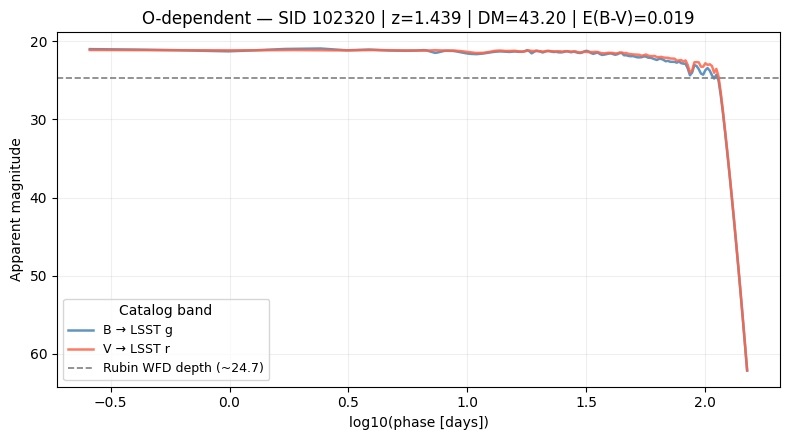


=== Apparent mag sample: Naive SFR ===


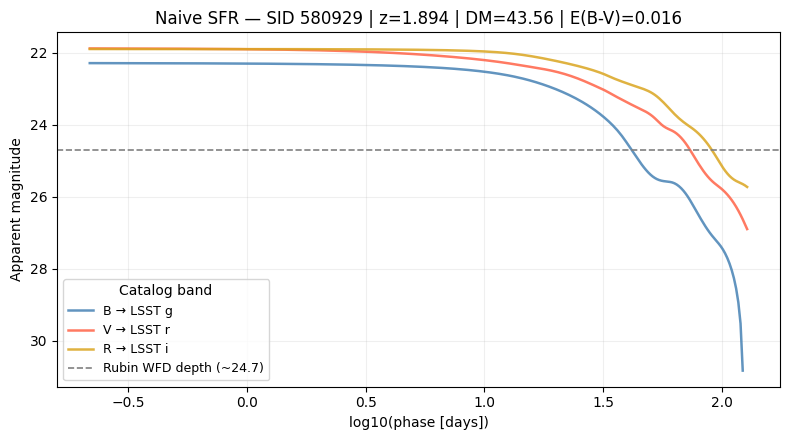

In [19]:
# ============================================================================
# CELL F: Population apparent mag — templates placed on the sky
# Shows 3 random events per model after distance modulus + Galactic extinction.
# Rubin WFD single-visit 5-sigma depth shown as dashed line (r~24.7).
# Requires: templates, pop_slicers (from Cell B), CATALOG_BANDS, BAND_MAP,
#           CAT_COLORS, _t_grid, _interp_band (defined in Cell E).
# Reload flags: NO reloads needed.
# ============================================================================
from rubin_sim.phot_utils import DustValues

dust_ax1   = DustValues().ax1   # LSST filter -> A_f / E(B-V)
N_POP_EVENTS = 3                # events per model to show
POP_SEED     = 42
RUBIN_DEPTH  = 24.7             # approximate WFD r-band 5-sigma single-visit depth

def _apparent_mag(tpl, cat_band, lsst_band, t_eval, dm, ebv):
    m_abs = _interp_band(tpl, cat_band, t_eval)
    A_f   = dust_ax1.get(lsst_band, 0.0) * ebv
    return m_abs + dm + A_f

for model in MODELS:
    print(f'\n=== Apparent mag sample: {model_labels[model]} ===')
    sp  = pop_slicers[model].slice_points
    n   = len(np.asarray(sp['z']).ravel())
    rng = np.random.default_rng(POP_SEED)
    sids = rng.choice(n, size=min(N_POP_EVENTS, n), replace=False)

    for sid in sids:
        idx      = int(np.asarray(sp['file_indx']).ravel()[sid])
        dist_mpc = float(np.asarray(sp['distance']).ravel()[sid])
        ebv      = float(np.asarray(sp['ebv']).ravel()[sid])
        z_val    = float(np.asarray(sp['z']).ravel()[sid])
        dm       = 5 * np.log10(dist_mpc * 1e6) - 5

        if idx >= len(templates.data):
            print(f'  SID {sid}: file_indx {idx} out of range'); continue
        tpl   = templates.data[idx]
        avail = [b for b in CATALOG_BANDS if b in tpl]
        if not avail:
            continue
        t_plot, t_eval = _t_grid(tpl, USE_LOG_TIME)
        if not t_eval.size:
            continue

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for b in avail:
            lsst_b = BAND_MAP[b]
            m_app  = _apparent_mag(tpl, b, lsst_b, t_eval, dm, ebv)
            fin    = np.isfinite(m_app)
            if fin.sum() < 2:
                continue
            ax.plot(t_plot[fin], m_app[fin], color=CAT_COLORS[b],
                    label=f'{b} \u2192 LSST {lsst_b}', lw=1.8, alpha=0.85)
        ax.axhline(RUBIN_DEPTH, ls='--', color='gray', lw=1.2,
                   label=f'Rubin WFD depth (~{RUBIN_DEPTH})')
        ax.invert_yaxis()
        ax.set_xlabel('log10(phase [days])' if USE_LOG_TIME else 'Phase [days]')
        ax.set_ylabel('Apparent magnitude')
        ax.set_title(
            f'{model_labels[model]} \u2014 SID {sid} | z={z_val:.3f} | '
            f'DM={dm:.2f} | E(B-V)={ebv:.3f}'
        )
        ax.legend(title='Catalog band', fontsize=9)
        ax.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()
